In [1]:
## First import general packages for running python analysis:
import os
import h5py
import datetime
import pytz,pickle, yaml, sys
import numpy as np
from matplotlib.pyplot import *
from matplotlib import pyplot as plt

## Then import the beamcals module, use forked repository (not original):
sys.path.insert(0, '../classes/')
import corr, concat, drone, phase
import plotting_utils as pu
import fitting_utils as fu
import geometry_utils as gu
import time_utils as tu
import site_utils as si
from datetime import datetime

In [10]:
import numpy as np

# Path to your file
npz_path = "../metadata/WLC_config_roof.npz"

# Load the file
data = np.load(npz_path, allow_pickle=True)

print("Keys in the NPZ file:")
print(data.files)
print("-" * 50)

# Loop through all stored arrays
for key in data.files:
    print(f"Key: {key}")
    
    array = data[key]
    
    print(f"Type: {type(array)}")
    print(f"Shape: {array.shape}")
    print(f"Dtype: {array.dtype}")
    
    print("Contents:")
    print(array)
    print("-" * 50)

Keys in the NPZ file:
['name', 'n_dishes', 'n_channels', 'chmap', 'keystrings', 'coords', 'pointings', 'polarizations', 'origin']
--------------------------------------------------
Key: name
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: <U8
Contents:
WLC_DISH
--------------------------------------------------
Key: n_dishes
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: int64
Contents:
1
--------------------------------------------------
Key: n_channels
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: int64
Contents:
2
--------------------------------------------------
Key: chmap
Type: <class 'numpy.ndarray'>
Shape: (2,)
Dtype: int64
Contents:
[2 3]
--------------------------------------------------
Key: keystrings
Type: <class 'numpy.ndarray'>
Shape: (2,)
Dtype: <U6
Contents:
['Cart_X' 'Cart_Y']
--------------------------------------------------
Key: coords
Type: <class 'numpy.ndarray'>
Shape: (2, 3)
Dtype: float64
Contents:
[[0. 0. 0.]
 [0. 0. 0.]]
-------------------------------------

In [11]:
import numpy as np

# Path to your file
npz_path = "../metadata/WLC_config_roof_shifted_origin_xy.npz"

# Load the file
data = np.load(npz_path, allow_pickle=True)

print("Keys in the NPZ file:")
print(data.files)
print("-" * 50)

# Loop through all stored arrays
for key in data.files:
    print(f"Key: {key}")
    
    array = data[key]
    
    print(f"Type: {type(array)}")
    print(f"Shape: {array.shape}")
    print(f"Dtype: {array.dtype}")
    
    print("Contents:")
    print(array)
    print("-" * 50)

Keys in the NPZ file:
['name', 'n_dishes', 'n_channels', 'chmap', 'keystrings', 'coords', 'pointings', 'polarizations', 'origin']
--------------------------------------------------
Key: name
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: <U8
Contents:
WLC_DISH
--------------------------------------------------
Key: n_dishes
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: int64
Contents:
1
--------------------------------------------------
Key: n_channels
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: int64
Contents:
2
--------------------------------------------------
Key: chmap
Type: <class 'numpy.ndarray'>
Shape: (2,)
Dtype: int64
Contents:
[2 3]
--------------------------------------------------
Key: keystrings
Type: <class 'numpy.ndarray'>
Shape: (2,)
Dtype: <U6
Contents:
['Cart_X' 'Cart_Y']
--------------------------------------------------
Key: coords
Type: <class 'numpy.ndarray'>
Shape: (2, 3)
Dtype: float64
Contents:
[[0. 0. 0.]
 [0. 0. 0.]]
-------------------------------------

In [12]:
ogsite= si.Site('../metadata/WLC_config_roof.npz')

sitedsite = si.Site('../metadata/WLC_config_roof_shifted_origin_xy.npz')

In [5]:
import os, glob, datetime
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from scipy.optimize import curve_fit
import pygeodesy

import sys
sys.path.insert(0, "../classes/")
import time_utils as tu

# --- progress bar (works in notebooks; falls back cleanly if not installed) ---
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def optimize_dish_xy(
    corr_dir_or_glob,
    dish_loc_baseline,
    fbin,
    corr_index,

    # ---- Flight 1 (2.5 m/s) ----
    drone_file_1,
    pass1a_range,
    pass1b_range,

    # ---- Flight 2 (5 m/s) ----
    drone_file_2,
    pass2a_range,
    pass2b_range,

    *,
    use_ctime=True,

    # Will-like pulse extraction defaults
    period_us=0.9999e6,
    duty_us=0.5e6,
    minmaxpercents=(0.0001, 100),
    channel_for_alignment=0,

    # Plot windows (what you SEE)
    plotwin_1a=(0, None),
    plotwin_1b=(0, None),
    plotwin_2a=(0, None),
    plotwin_2b=(0, None),

    # ==========================================================
    # per-flight expected peak width (seconds)
    #   - Applied to BOTH distance+power fits within that flight
    #   - Applied to BOTH passes (A/B) in that flight
    # ==========================================================
    peak_width_s_flight1=2.0,   # e.g. 2.5 m/s flight
    peak_width_s_flight2=1.0,   # e.g. 5 m/s flight
    peak_width_is_full=True,

    # Optimization grid over dish XY (meters)
    bound_m=10.0,
    step_m=0.1,
    objective="rms",          # "rms" or "l1" or "max"

    # Soft prior to prevent runaway-to-boundary solutions
    prior_sigma_m=None,       # None disables; else adds (east^2+north^2)/prior_sigma_m^2 penalty
    prior_center_m=(0.0, 0.0),

    # Table display
    table_font_px=14,
    table_width_pct=60,

    # Plots
    show_fit_plots=True,              # baseline 4 plots
    show_optimized_fit_plots=False,   # legacy toggle: optimized 4 plots
    show_final_fit_plots=True,        # NEW: always re-plot the 4 plots using the best-shifted dish (same order as baseline)

    # progress bar toggle
    show_progress=True,
):
    """
    Change in this version:
      - After the best (east,north) shift is found, optionally reproduces the SAME four plots
        (1A,1B,2A,2B) but using the updated dish position (i.e., distance recomputed relative
        to the optimized dish), so the drone minima / fit / marker move accordingly.

    Notes:
      - This does NOT change the optimization logic.
      - The correlator power fit is unchanged (same ON bins); only the drone-distance curve
        changes with dish shift, which moves the minimum and the quadratic fit window.
    """

    # ==========================================================
    # Models
    # ==========================================================
    def quad_vertex(t, a, t0, c):
        return a * (t - t0) ** 2 + c

    def gauss_linear(t, A, mu, sigma, m, b):
        return A * np.exp(-(t - mu) ** 2 / (2 * sigma ** 2)) + (m * t + b)

    def pm(val, sig):
        return f"{val:.6f} ± {sig:.6f}" if np.isfinite(sig) else f"{val:.6f} ± ?"

    def halfwidth_from_peakwidth(w):
        w = float(w)
        return 0.5 * w if peak_width_is_full else w

    # ==========================================================
    # Correlator helpers
    # ==========================================================
    def list_corr_files(path):
        if os.path.isdir(path):
            return sorted(os.path.join(path, f) for f in os.listdir(path) if ".lock" not in f)
        return sorted(f for f in glob.glob(path) if ".lock" not in f)

    def read_corr_range(files, s, e):
        sel = files[s:] if e == -1 else files[s:e]
        if len(sel) == 0:
            raise ValueError(f"No correlator files in range [{s}:{e}]")
        vis, time_arr = None, None
        for k, fp in enumerate(sel):
            with h5py.File(fp, "r") as f:
                idx = f["index_map"]
                if k == 0:
                    vis = f["vis"][:]
                    time_arr = idx["time"][:]
                else:
                    vis = np.append(vis, f["vis"][:], axis=0)
                    time_arr = np.append(time_arr, idx["time"][:])

        class Corr: pass
        c = Corr()
        c.vis = vis
        c.time = time_arr
        return c

    def get_mag(v):
        return np.abs(v)

    # ==========================================================
    # Robust drone loader
    # ==========================================================
    def load_drone(csv):
        df = pd.read_csv(csv, low_memory=False)

        # --- time ---
        if "datetime(utc)" in df.columns and "time(millisecond)" in df.columns:
            t0 = pd.to_datetime(df["datetime(utc)"], utc=True).iloc[0]
            times = np.array([(t0 + datetime.timedelta(milliseconds=x)).timestamp()
                              for x in df["time(millisecond)"]], dtype=float)
        elif "GPS:dateTimeStamp" in df.columns:
            times = pd.to_datetime(df["GPS:dateTimeStamp"], utc=True)\
                        .map(lambda t: t.timestamp()).values.astype(float)
        else:
            raise KeyError(
                "No recognizable time columns in drone file. "
                "Expected ('datetime(utc)' + 'time(millisecond)') or 'GPS:dateTimeStamp'."
            )

        # --- position candidates ---
        candidates = [
            ("RTKdata:Lat_P", "RTKdata:Lon_P", "RTKdata:Hmsl_P"),
            ("GPS(0):Lat", "GPS(0):Long", "GPS(0):heightMSL"),
            ("GPS:Lat", "GPS:Long", "GPS:heightMSL"),
            ("GPS:Lat", "GPS:Lon", "GPS:heightMSL"),
            ("latitude", "longitude", "altitude(meters)"),
            ("latitude", "longitude", "altitude(feet)"),
        ]

        lat = lon = alt = None
        alt_is_feet = False
        for a, b, c in candidates:
            if a in df.columns and b in df.columns and c in df.columns:
                lat = df[a].values
                lon = df[b].values
                alt = df[c].values
                alt_is_feet = (c == "altitude(feet)")
                break

        if lat is None:
            cols = list(df.columns)
            lat_like = [x for x in cols if "lat" in x.lower()]
            lon_like = [x for x in cols if "lon" in x.lower() or "long" in x.lower()]
            alt_like = [x for x in cols if "alt" in x.lower() or "hmsl" in x.lower() or "height" in x.lower()]
            raise KeyError(
                "Could not find recognizable lat/lon/alt columns in drone CSV.\n"
                f"Lat-like columns: {lat_like[:15]}\n"
                f"Lon/Long-like columns: {lon_like[:15]}\n"
                f"Alt/Height-like columns: {alt_like[:15]}"
            )

        lat = np.asarray(lat, dtype=float)
        lon = np.asarray(lon, dtype=float)
        alt = np.asarray(alt, dtype=float)
        if alt_is_feet:
            alt = alt * 0.3048

        valid = np.isfinite(times) & np.isfinite(lat) & np.isfinite(lon) & np.isfinite(alt)
        if not np.any(valid):
            raise ValueError("No valid (finite) time/lat/lon/alt rows found after parsing drone CSV.")

        return times[valid], lat[valid], lon[valid], alt[valid]

    # ==========================================================
    # ENU conversion (baseline dish only)
    # ==========================================================
    def drone_to_enu(lat, lon, alt, dish):
        origin = pygeodesy.EcefCartesian(latlonh0=dish[0], lon0=dish[1], height0=dish[2])
        out = np.zeros((len(lat), 3))
        for i in range(len(lat)):
            p = pygeodesy.ellipsoidalNvector.LatLon(lat[i], lon[i], height=alt[i])
            out[i] = origin.forward(p).toVector()
        return out

    # ==========================================================
    # Small-angle EN → lat/lon
    # ==========================================================
    def shifted_latlon(lat0, lon0, east_m, north_m):
        R = 6378137.0
        dlat = north_m / R
        dlon = east_m / (R * np.cos(np.deg2rad(lat0)))
        return lat0 + np.rad2deg(dlat), lon0 + np.rad2deg(dlon)

    # ==========================================================
    # Will-style pulse extraction (exact logic)
    # ==========================================================
    def extract_source_pulses_like_will(corr, *, t_bounds=(0, -1)):
        delta_time = np.diff(corr.time["irigb_time"])[1] * 1e-9
        concat_duration = int(np.ceil(delta_time * len(corr.vis)))

        time_s, time_dt, switch = tu.Pulsed_Data_Waveform(
            total_duration=concat_duration,
            period=period_us,
            duty_cycle_on=duty_us,
        )

        num_bins = corr.vis.shape[0]
        time_bin_width = np.diff(corr.time["irigb_time"])[1] * 1e-9
        t_full = np.arange(num_bins) * time_bin_width

        t_offset_dist = np.arange(-1.0 * period_us * 1e-6, 0.0, 0.001)

        tb0, tb1 = t_bounds
        t_hi = t_full[-1] if tb1 == -1 else t_full[tb1]
        t_lo = t_full[tb0]
        sniparr = np.where(time_s[np.where(time_s <= t_hi)[0]] >= t_lo)[0]

        n_channels = 3
        Pr_arr = np.NaN * np.ones((n_channels, t_offset_dist.shape[0]))
        Pr_max_t_0_per_channel = np.NaN * np.ones(n_channels)

        for i in range(n_channels):
            chan = channel_for_alignment + i
            if chan >= corr.vis.shape[2]:
                raise IndexError(
                    f"Alignment channel {chan} out of bounds for corr.vis {corr.vis.shape}. "
                    f"Lower channel_for_alignment."
                )

            minsubdata = corr.vis[:, fbin, chan] - np.percentile(corr.vis[:, fbin, chan], minmaxpercents[0])
            normminsubdata = minsubdata / np.percentile(minsubdata, minmaxpercents[1])
            clipnormminsubdata = np.clip(normminsubdata, 0, 1)

            stepped_func = interp1d(t_full, clipnormminsubdata, kind="previous", fill_value="extrapolate")
            t_restrict = np.intersect1d(
                np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],
                sniparr
            )

            for j, t_offset in enumerate(t_offset_dist):
                shiftedswitch = np.interp(time_s, time_s + t_offset, switch)
                try:
                    Pr_arr[i, j] = pearsonr(
                        stepped_func(time_s[t_restrict]).real,
                        shiftedswitch[t_restrict]
                    )[0]
                except ValueError:
                    Pr_arr[i, j] = np.nan

            if np.isfinite(np.nanmax(Pr_arr[i, :])):
                maxPrind = np.where(Pr_arr[i, :] == np.nanmax(Pr_arr[i, :]))[0][0]
                Pr_max_t_0_per_channel[i] = t_offset_dist[maxPrind]

        t_delta_pulse = float(Pr_max_t_0_per_channel[0])

        t_for_interp_out = np.arange(num_bins) * time_bin_width
        t_for_interp_in = np.array([m.total_seconds() for m in time_dt])
        switch_interp_f = np.interp(t_for_interp_out, t_for_interp_in + t_delta_pulse, switch)

        inds_span = np.union1d(
            list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),
            np.intersect1d(np.where(1 > switch_interp_f), np.where(switch_interp_f > 0))
        ).tolist()
        inds_span = np.asarray(sorted(set(inds_span)), dtype=int)

        inds_on = np.asarray(sorted(list(set(np.where(switch_interp_f == 1)[0]) - set(inds_span))), dtype=int)
        inds_off = np.asarray(sorted(list(set(np.where(switch_interp_f == 0)[0]) - set(inds_span))), dtype=int)

        return inds_on, inds_off, inds_span, t_delta_pulse

    # ==========================================================
    # Objective
    # ==========================================================
    def compute_objective(ddt1, ddt2, how, east, north):
        a, b = float(ddt1), float(ddt2)
        if how == "l1":
            base = abs(a) + abs(b)
        elif how == "max":
            base = max(abs(a), abs(b))
        else:
            base = float(np.sqrt(0.5 * (a*a + b*b)))

        if prior_sigma_m is not None and np.isfinite(prior_sigma_m) and prior_sigma_m > 0:
            e0, n0 = prior_center_m
            pen = ((east - e0)**2 + (north - n0)**2) / (prior_sigma_m**2)
            return base + pen
        return base

    # ==========================================================
    # Plot helper (one pass)
    # ==========================================================
    def plot_pass(result, title, plotwin):
        t = result["t_plot"]
        d = result["d_plot"]
        m = result["m_plot"]

        t_fit = result["t_fit"]

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

        ax1.plot(t, d, ".", color="black", label="Distance data")
        ax1.plot(t_fit, quad_vertex(t_fit, *result["popt_d"]), "-", color="red", linewidth=2, label="Quadratic fit")
        ax1.axvline(result["t0_d"], color="red", linestyle="--", linewidth=2, label=f"min @ {result['t0_d']:.3f}s")
        ax1.set_ylabel("Distance (m)")
        ax1.set_title(title)
        ax1.grid(True)
        ax1.legend()

        ax2.plot(t, m, ".", color="purple", alpha=0.6, label="Power data")
        ax2.plot(t_fit, gauss_linear(t_fit, *result["popt_p"]), "-", color="blue", linewidth=2, label="Gaussian + linear fit")
        ax2.axvline(result["mu_p"], color="blue", linestyle="--", linewidth=2, label=f"peak @ {result['mu_p']:.3f}s")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylabel("Power magnitude")
        ax2.grid(True)
        ax2.legend()

        if plotwin[1] is not None:
            ax2.set_xlim(plotwin[0], plotwin[1])

        plt.tight_layout()
        plt.show()

    # ==========================================================
    # Build pass cache (stores baseline ENU, ON bins, power fit)
    # ==========================================================
    def build_pass_cache(prange, drone_times, enu_base, plotwin, files, peak_width_s):
        halfw = halfwidth_from_peakwidth(peak_width_s)

        s, e = prange
        corr = read_corr_range(files, s, e)

        inds_on, inds_off, inds_span, t_delta_pulse = extract_source_pulses_like_will(corr, t_bounds=(0, -1))
        if len(inds_on) < 8:
            raise ValueError(f"Too few ON bins for pass range {prange}: {len(inds_on)}")

        corr_epoch = np.array([float(t[-1]) for t in corr.time], dtype=float)

        times_dt_all = [datetime.datetime.utcfromtimestamp(t[-1]) for t in corr.time]
        times_dt_sel = [times_dt_all[i] for i in inds_on]
        t_on = np.array([(tt - times_dt_sel[0]).total_seconds() for tt in times_dt_sel], dtype=float)

        mag_all = get_mag(corr.vis)[:, fbin, corr_index]
        mag_on = mag_all[inds_on]

        # baseline ENU interpolation onto corr epoch
        E_all = np.interp(corr_epoch, drone_times, enu_base[:, 0])
        N_all = np.interp(corr_epoch, drone_times, enu_base[:, 1])
        U_all = np.interp(corr_epoch, drone_times, enu_base[:, 2])

        E_on = E_all[inds_on]
        N_on = N_all[inds_on]
        U_on = U_all[inds_on]

        p0 = float(plotwin[0]) if plotwin[0] is not None else float(t_on.min())
        p1 = float(plotwin[1]) if plotwin[1] is not None else float(t_on.max())
        m_plot = (t_on >= p0) & (t_on <= p1)

        t_plot = t_on[m_plot]
        mag_plot = mag_on[m_plot]
        E_plot = E_on[m_plot]
        N_plot = N_on[m_plot]
        U_plot = U_on[m_plot]

        if len(t_plot) < 12:
            raise ValueError(f"Plot window {plotwin} leaves too few ON samples for pass {prange}: {len(t_plot)}")

        # power peak fit window around the peak in the plotted region
        i_pk = int(np.argmax(mag_plot))
        mu_guess = float(t_plot[i_pk])
        mp = np.abs(t_plot - mu_guess) <= halfw
        if mp.sum() < 10:
            keep = np.argsort(np.abs(t_plot - mu_guess))[:max(10, min(25, len(t_plot)))]
            mp = np.isin(np.arange(len(t_plot)), keep)

        t_pow = t_plot[mp]
        y_pow = mag_plot[mp]

        n_edge = max(5, int(0.2 * len(t_pow)))
        t_edges = np.concatenate([t_pow[:n_edge], t_pow[-n_edge:]])
        y_edges = np.concatenate([y_pow[:n_edge], y_pow[-n_edge:]])
        m_guess, b_guess = np.polyfit(t_edges, y_edges, 1)

        A_guess = float(np.max(y_pow) - (m_guess * mu_guess + b_guess))
        sigma_guess = max(1e-3, 0.35 * halfw)

        popt_p, pcov_p = curve_fit(
            gauss_linear, t_pow, y_pow,
            p0=[max(A_guess, 1e-12), mu_guess, sigma_guess, m_guess, b_guess],
            maxfev=30000
        )
        mu_p = float(popt_p[1])
        sig_mu = float(np.sqrt(pcov_p[1, 1])) if np.isfinite(pcov_p[1, 1]) else np.nan

        return {
            "prange": prange,
            "plotwin": (p0, p1),
            "t_plot": t_plot,
            "mag_plot": mag_plot,
            "E_plot": E_plot,
            "N_plot": N_plot,
            "U_plot": U_plot,
            "popt_p": popt_p,
            "mu_p": mu_p,
            "sig_mu": sig_mu,
            "peak_halfw_s": float(halfw),
            "meta": {
                "ON": int(len(inds_on)),
                "OFF": int(len(inds_off)),
                "SPAN": int(len(inds_span)),
                "t_delta_pulse": float(t_delta_pulse),
            }
        }

    # ==========================================================
    # Evaluate pass for a given (east,north) dish shift
    # ==========================================================
    def eval_pass_for_shift(cache, east_m, north_m):
        t = cache["t_plot"]
        halfw = cache["peak_halfw_s"]

        # shift dish in EN plane => subtract shift from drone EN coords
        E = cache["E_plot"] - east_m
        N = cache["N_plot"] - north_m
        U = cache["U_plot"]
        d = np.sqrt(E**2 + N**2 + U**2)

        i_min = int(np.argmin(d))
        t0_guess = float(t[i_min])
        md = np.abs(t - t0_guess) <= halfw
        if md.sum() < 8:
            keep = np.argsort(np.abs(t - t0_guess))[:max(8, min(20, len(t)))]
            md = np.isin(np.arange(len(t)), keep)

        t_dist = t[md]
        y_dist = d[md]

        popt_d, pcov_d = curve_fit(
            quad_vertex, t_dist, y_dist,
            p0=[1.0, t0_guess, float(np.min(y_dist))],
            maxfev=20000
        )
        t0_d = float(popt_d[1])
        sig_t0 = float(np.sqrt(pcov_d[1, 1])) if np.isfinite(pcov_d[1, 1]) else np.nan

        mu_p = cache["mu_p"]
        sig_mu = cache["sig_mu"]

        dt_val = float(mu_p - t0_d)
        sig_dt = float(np.sqrt(sig_mu**2 + sig_t0**2)) if (np.isfinite(sig_mu) and np.isfinite(sig_t0)) else np.nan

        t_fit = np.linspace(cache["plotwin"][0], cache["plotwin"][1], 1200)

        return {
            "t_plot": t,
            "d_plot": d,
            "m_plot": cache["mag_plot"],
            "t_fit": t_fit,
            "popt_d": popt_d,
            "popt_p": cache["popt_p"],
            "t0_d": t0_d,
            "mu_p": mu_p,
            "dt": dt_val,
            "sig": sig_dt,
            "meta": cache["meta"],
        }

    # ==========================================================
    # Table helper
    # ==========================================================
    def make_table(p1a, p1b, p2a, p2b):
        ddt1 = p1b["dt"] - p1a["dt"]
        ddt2 = p2b["dt"] - p2a["dt"]
        sig_ddt1 = np.sqrt(p1a["sig"]**2 + p1b["sig"]**2) if (np.isfinite(p1a["sig"]) and np.isfinite(p1b["sig"])) else np.nan
        sig_ddt2 = np.sqrt(p2a["sig"]**2 + p2b["sig"]**2) if (np.isfinite(p2a["sig"]) and np.isfinite(p2b["sig"])) else np.nan

        table = pd.DataFrame({
            "Flight": ["2.5 m/s", "5 m/s"],
            "Δt Pass A (s)": [pm(p1a["dt"], p1a["sig"]), pm(p2a["dt"], p2a["sig"])],
            "Δt Pass B (s)": [pm(p1b["dt"], p1b["sig"]), pm(p2b["dt"], p2b["sig"])],
            "ΔΔt = B − A (s)": [pm(ddt1, sig_ddt1), pm(ddt2, sig_ddt2)],
        })
        return table, (ddt1, ddt2)

    def show_table(table, title):
        print(f"\n=== {title} ===")
        display(
            table.style.set_table_styles([
                {"selector": "th", "props": [("font-size", f"{table_font_px}px")]},
                {"selector": "td", "props": [("font-size", f"{table_font_px}px")]},
                {"selector": "table", "props": [("width", f"{table_width_pct}%")]},
            ])
        )

    # ==========================================================
    # Load data + build caches
    # ==========================================================
    files = list_corr_files(corr_dir_or_glob)
    if len(files) == 0:
        raise ValueError("No correlator files found from corr_dir_or_glob.")

    t1, lat1, lon1, alt1 = load_drone(drone_file_1)
    t2, lat2, lon2, alt2 = load_drone(drone_file_2)

    enu1_base = drone_to_enu(lat1, lon1, alt1, dish_loc_baseline)
    enu2_base = drone_to_enu(lat2, lon2, alt2, dish_loc_baseline)

    cache_1a = build_pass_cache(pass1a_range, t1, enu1_base, plotwin_1a, files, peak_width_s_flight1)
    cache_1b = build_pass_cache(pass1b_range, t1, enu1_base, plotwin_1b, files, peak_width_s_flight1)
    cache_2a = build_pass_cache(pass2a_range, t2, enu2_base, plotwin_2a, files, peak_width_s_flight2)
    cache_2b = build_pass_cache(pass2b_range, t2, enu2_base, plotwin_2b, files, peak_width_s_flight2)

    # ==========================================================
    # Baseline (no shift)
    # ==========================================================
    base_1a = eval_pass_for_shift(cache_1a, 0.0, 0.0)
    base_1b = eval_pass_for_shift(cache_1b, 0.0, 0.0)
    base_2a = eval_pass_for_shift(cache_2a, 0.0, 0.0)
    base_2b = eval_pass_for_shift(cache_2b, 0.0, 0.0)

    table_base, _ = make_table(base_1a, base_1b, base_2a, base_2b)
    show_table(table_base, "Baseline dish location (no shift)")

    if show_fit_plots:
        def title_line(speed_label, pass_label, meta):
            return (f"{speed_label} – Pass {pass_label} (baseline)  "
                    f"(ON={meta['ON']}, OFF={meta['OFF']}, SPAN={meta['SPAN']}, tΔ={meta['t_delta_pulse']:.3f}s)")
        plot_pass(base_1a, title_line("2.5 m/s", "A", base_1a["meta"]), cache_1a["plotwin"])
        plot_pass(base_1b, title_line("2.5 m/s", "B", base_1b["meta"]), cache_1b["plotwin"])
        plot_pass(base_2a, title_line("5 m/s", "A", base_2a["meta"]), cache_2a["plotwin"])
        plot_pass(base_2b, title_line("5 m/s", "B", base_2b["meta"]), cache_2b["plotwin"])

    # ==========================================================
    # Optimization grid search (with optional progress bar)
    # ==========================================================
    east_vals = np.arange(-bound_m, bound_m + 0.5 * step_m, step_m)
    north_vals = np.arange(-bound_m, bound_m + 0.5 * step_m, step_m)

    n_total = len(east_vals) * len(north_vals)

    use_pbar = (tqdm is not None) and bool(show_progress)
    pbar = tqdm(total=n_total, desc="Grid search (east,north)", unit="pt") if use_pbar else None

    obj_grid = np.zeros((len(north_vals), len(east_vals)))

    best = {"obj": np.inf, "east": 0.0, "north": 0.0, "results": None}

    try:
        for i_e, east in enumerate(east_vals):
            for i_n, north in enumerate(north_vals):

                r1a = eval_pass_for_shift(cache_1a, east, north)
                r1b = eval_pass_for_shift(cache_1b, east, north)
                r2a = eval_pass_for_shift(cache_2a, east, north)
                r2b = eval_pass_for_shift(cache_2b, east, north)

                ddt1 = r1b["dt"] - r1a["dt"]
                ddt2 = r2b["dt"] - r2a["dt"]

                objv = compute_objective(ddt1, ddt2, objective, east, north)

                obj_grid[i_n, i_e] = objv

                if objv < best["obj"]:
                    best = {
                        "obj": objv,
                        "east": float(east),
                        "north": float(north),
                        "results": (r1a, r1b, r2a, r2b)
                    }

                if pbar is not None:
                    pbar.update(1)

    finally:
        if pbar is not None:
            pbar.close()
    
    opt_1a, opt_1b, opt_2a, opt_2b = best["results"]
    table_opt, _ = make_table(opt_1a, opt_1b, opt_2a, opt_2b)
    show_table(table_opt, "Optimized dish location (after grid search)")
    
        # ==========================================================
        # Diagnostic grid visualization
        # ==========================================================
    plt.figure(figsize=(8,7))

    extent = [
        east_vals.min(), east_vals.max(),
        north_vals.min(), north_vals.max()
    ]

    im = plt.imshow(
        obj_grid,
        origin="lower",
        extent=extent,
        aspect="auto",
        cmap="viridis"
    )

    plt.colorbar(im, label="Objective value")

    # ----------------------------------------------------------
    # Overlay drone flight tracks (same ENU coordinate system)
    # ----------------------------------------------------------
    plt.plot(
        enu1_base[:,0],
        enu1_base[:,1],
        ".",
        color="white",
        alpha=0.35,
        markersize=30,
        label="Drone path flight 1"
    )

    plt.plot(
        enu2_base[:,0],
        enu2_base[:,1],
        ".",
        color="cyan",
        alpha=0.35,
        markersize=30,
        label="Drone path flight 2"
    )

    # ----------------------------------------------------------
    # Dish locations
    # ----------------------------------------------------------

    # Baseline dish
    plt.scatter(
        0, 0,
        color="black",
        s=120,
        marker="o",
        edgecolor="white",
        linewidth=1.5,
        label="Baseline dish"
    )

    # Optimized dish
    plt.scatter(
        best["east"],
        best["north"],
        color="red",
        s=150,
        marker="x",
        linewidths=3,
        label="Optimized dish"
    )

    plt.xlabel("East shift (m)")
    plt.ylabel("North shift (m)")
    plt.title("Dish Position Optimization Surface")

    plt.legend()

    # ---- lock plot limits to optimization grid ----
    plt.xlim(east_vals.min(), east_vals.max())
    plt.ylim(north_vals.min(), north_vals.max())

    plt.tight_layout()
    plt.show()

    # Suggested shift + new coords
    lat0, lon0, h0 = dish_loc_baseline
    lat_new, lon_new = shifted_latlon(lat0, lon0, best["east"], best["north"])

    print("\n=== Suggested Dish Location Update (from optimization) ===")
    print(f"Objective ({objective}) : {best['obj']:.6e}")
    if prior_sigma_m is not None:
        print(f"Prior enabled           : sigma={prior_sigma_m} m, center={prior_center_m}")
    print(f"East shift              : {best['east']:+.3f} m")
    print(f"North shift             : {best['north']:+.3f} m")
    print(f"New latitude            : {lat_new:.10f}")
    print(f"New longitude           : {lon_new:.10f}")
    print(f"(Altitude unchanged)    : {h0:.3f} m")
    
    

    # ==========================================================
    # NEW: Reproduce the same four plots with the UPDATED dish shift
    # ==========================================================
    if show_final_fit_plots or show_optimized_fit_plots:
        def title_line_updated(speed_label, pass_label, meta):
            return (f"{speed_label} – Pass {pass_label} (updated dish)  "
                    f"(ΔE={best['east']:+.2f} m, ΔN={best['north']:+.2f} m)  "
                    f"(ON={meta['ON']}, OFF={meta['OFF']}, SPAN={meta['SPAN']}, tΔ={meta['t_delta_pulse']:.3f}s)")

        # Same order as baseline: 1A, 1B, 2A, 2B
        plot_pass(opt_1a, title_line_updated("2.5 m/s", "A", opt_1a["meta"]), cache_1a["plotwin"])
        plot_pass(opt_1b, title_line_updated("2.5 m/s", "B", opt_1b["meta"]), cache_1b["plotwin"])
        plot_pass(opt_2a, title_line_updated("5 m/s", "A", opt_2a["meta"]), cache_2a["plotwin"])
        plot_pass(opt_2b, title_line_updated("5 m/s", "B", opt_2b["meta"]), cache_2b["plotwin"])

    return {
        "baseline_table": table_base,
        "optimized_table": table_opt,
        "best_shift_m": {best["north"]},
        "best_results": {"1a": opt_1a, "1b": opt_1b, "2a": opt_2a, "2b": opt_2b},
    }



=== Baseline dish location (no shift) ===


,Flight,Δt Pass A (s),Δt Pass B (s),ΔΔt = B − A (s)
0,2.5 m/s,2.164411 ± 0.022474,2.474659 ± 0.031691,0.310249 ± 0.038851
1,5 m/s,2.164411 ± 0.022474,2.474659 ± 0.031691,0.310249 ± 0.038851


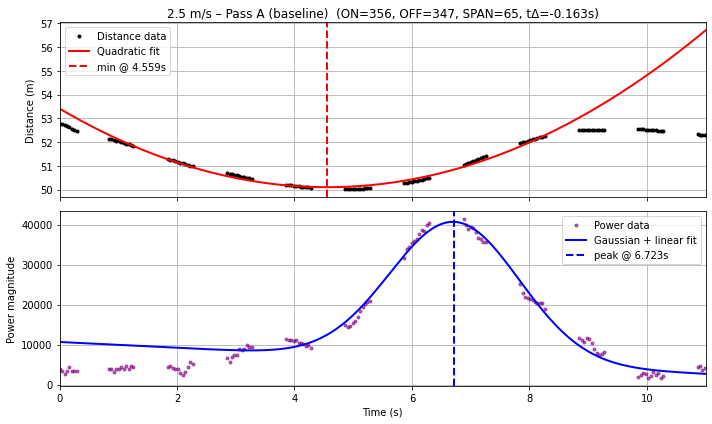

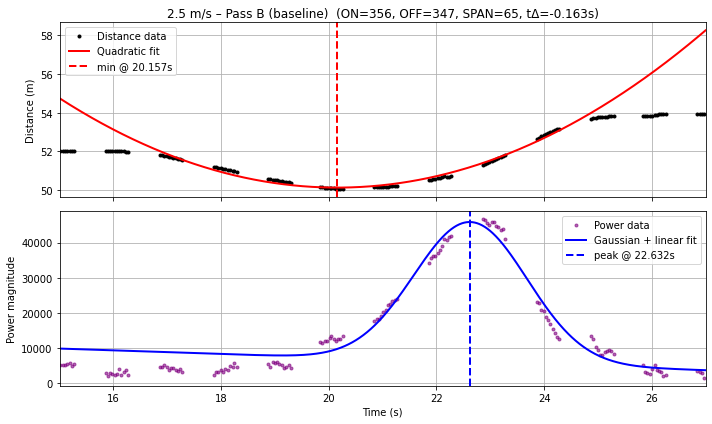

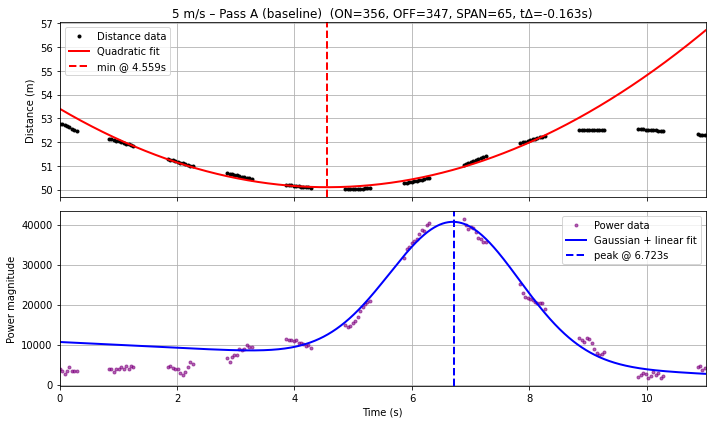

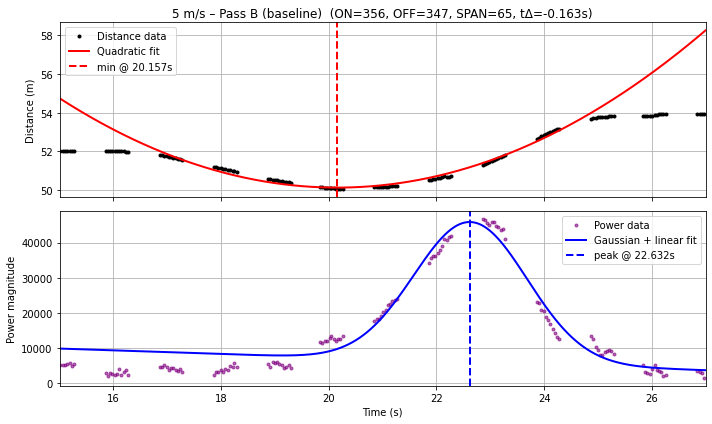

Grid search (east,north):   0%|          | 0/441 [00:00<?, ?pt/s]


=== Optimized dish location (after grid search) ===


,Flight,Δt Pass A (s),Δt Pass B (s),ΔΔt = B − A (s)
0,2.5 m/s,2.317794 ± 0.022813,2.330038 ± 0.031869,0.012244 ± 0.039193
1,5 m/s,2.317794 ± 0.022813,2.330038 ± 0.031869,0.012244 ± 0.039193


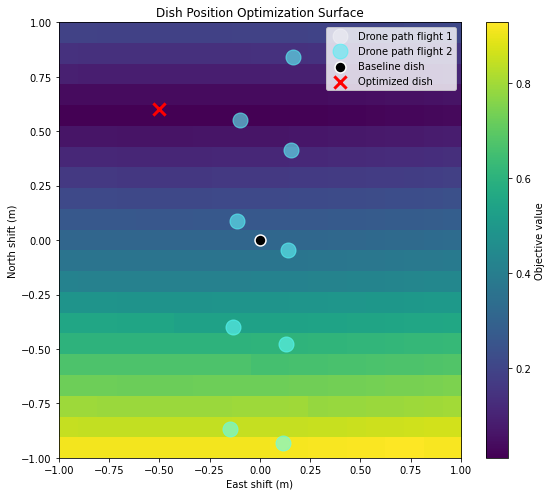


=== Suggested Dish Location Update (from optimization) ===
Objective (rms) : 1.234441e-02
Prior enabled           : sigma=10 m, center=(-0.5, 0.5)
East shift              : -0.500 m
North shift             : +0.600 m
New latitude            : 41.3190047259
New longitude           : -72.9213261750
(Altitude unchanged)    : 25.000 m


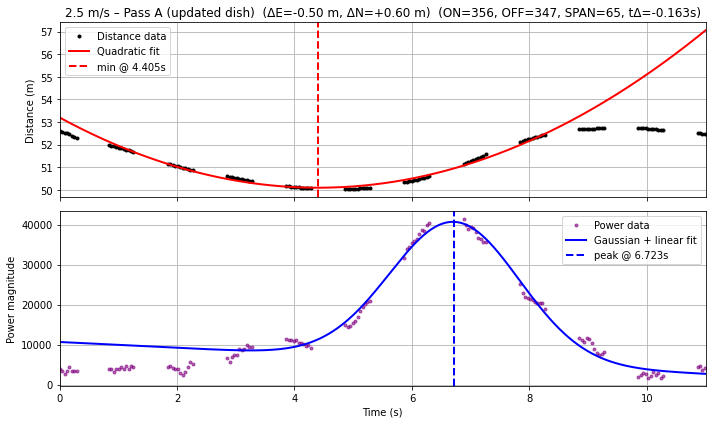

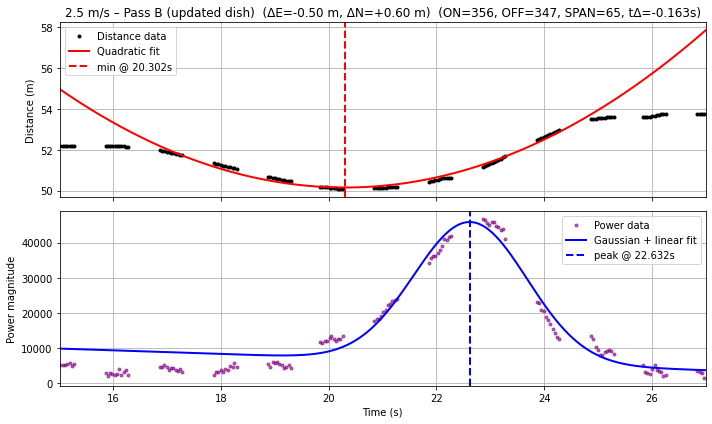

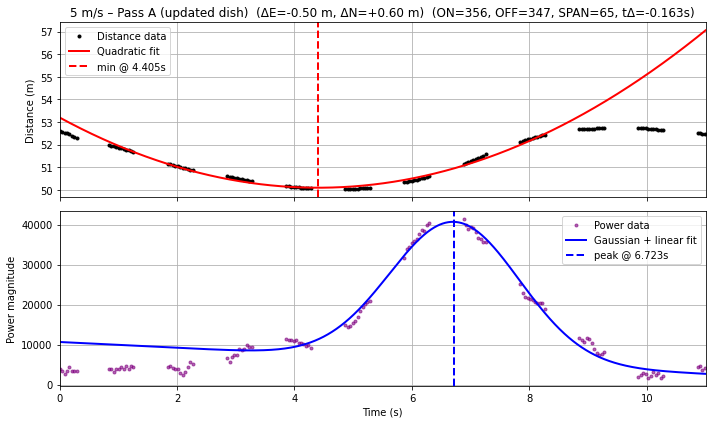

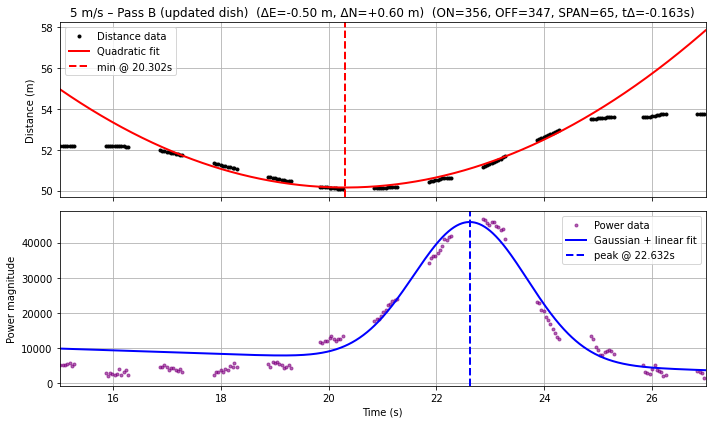

In [6]:
# Call cell (updated to include final re-plot with updated dish shift)
results = optimize_dish_xy(
    corr_dir_or_glob="/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z",
    dish_loc_baseline=ogsite.origin, #(41.31899934, -72.92132019, 25),
    fbin=350,
    corr_index=8,

#      drone_file_1="../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-03-58PM-Flight-Airdata.csv",
#      pass1a_range=(99, 102),
#      pass1b_range=(101, 104),

    
    drone_file_1="../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-04-03PM-Flight-Airdata.csv",
    pass1a_range=(128, 131),
    pass1b_range=(128, 131),
    
    drone_file_2="../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-04-03PM-Flight-Airdata.csv",
    pass2a_range=(128, 131),
    pass2b_range=(128, 131),

    # Plot windows (what you SEE)
    #plotwin_1a=(8, 25),
    #plotwin_1b=(7, 24),
     plotwin_1a=(0, 11),
     plotwin_1b=(15, 27),

     plotwin_2a=(0, 11),
     plotwin_2b=(15, 27),

    # Expected peak widths (seconds) per flight:
    # - 2.5 m/s is typically ~2× wider than 5 m/s
    #peak_width_s_flight1=12.0,
    peak_width_s_flight1=8.0,
    peak_width_s_flight2=8.0,
    peak_width_is_full=True,

    bound_m=1,
    step_m=.1,
    objective="rms",

    prior_sigma_m=10,
    prior_center_m=(-.5, .5),

    table_font_px=14,
    table_width_pct=60,

    # Baseline plots (original dish)
    show_fit_plots=True,

    # Keep this off unless you explicitly want the older "optimized plots" toggle
    show_optimized_fit_plots=False,

    # NEW: after optimization, reproduce the same 4 plots using the updated dish shift
    show_final_fit_plots=True,

    # Progress bar during grid search (uses tqdm if available)
    show_progress=True,
)


In [7]:
import os, glob, datetime
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.stats import pearsonr
from scipy.optimize import curve_fit
import pygeodesy

import sys
sys.path.insert(0, "../classes/")
import time_utils as tu

# --- progress bar (works in notebooks; falls back cleanly if not installed) ---
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def optimize_dish_t(
    corr_dir_or_glob,
    dish_loc_baseline,
    fbin,
    corr_index,

    # ---- Flight 1 (2.5 m/s) ----
    drone_file_1,
    pass1a_range,
    pass1b_range,

    # ---- Flight 2 (5 m/s) ----
    drone_file_2,
    pass2a_range,
    pass2b_range,

    *,
    use_ctime=True,

    # Will-like pulse extraction defaults
    period_us=0.9999e6,
    duty_us=0.5e6,
    minmaxpercents=(0.0001, 100),
    channel_for_alignment=0,

    # Plot windows (what you SEE)
    plotwin_1a=(0, None),
    plotwin_1b=(0, None),
    plotwin_2a=(0, None),
    plotwin_2b=(0, None),
    
    og_e_shift=-.5,
    og_n_shift=.6,
    

    # ==========================================================
    # per-flight expected peak width (seconds)
    #   - Applied to BOTH distance+power fits within that flight
    #   - Applied to BOTH passes (A/B) in that flight
    # ==========================================================
    peak_width_s_flight1=2.0,   # e.g. 2.5 m/s flight
    peak_width_s_flight2=1.0,   # e.g. 5 m/s flight
    peak_width_is_full=True,

    # Optimization grid over dish XY (meters)
    bound_m=10.0,
    step_m=0.1,
    objective="rms",          # "rms" or "l1" or "max"

    # Soft prior to prevent runaway-to-boundary solutions
    prior_sigma_m=None,       # None disables; else adds (east^2+north^2)/prior_sigma_m^2 penalty
    prior_center_m=(0.0, 0.0),

    # Table display
    table_font_px=14,
    table_width_pct=60,

    # Plots
    show_fit_plots=True,              # baseline 4 plots
    show_optimized_fit_plots=False,   # legacy toggle: optimized 4 plots
    show_final_fit_plots=True,        # NEW: always re-plot the 4 plots using the best-shifted dish (same order as baseline)

    # progress bar toggle
    show_progress=True,
):
    """
    Change in this version:
      - After the best (east,north) shift is found, optionally reproduces the SAME four plots
        (1A,1B,2A,2B) but using the updated dish position (i.e., distance recomputed relative
        to the optimized dish), so the drone minima / fit / marker move accordingly.

    Notes:
      - This does NOT change the optimization logic.
      - The correlator power fit is unchanged (same ON bins); only the drone-distance curve
        changes with dish shift, which moves the minimum and the quadratic fit window.
    """

    # ==========================================================
    # Models
    # ==========================================================
    def quad_vertex(t, a, t0, c):
        return a * (t - t0) ** 2 + c

    def gauss_linear(t, A, mu, sigma, m, b):
        return A * np.exp(-(t - mu) ** 2 / (2 * sigma ** 2)) + (m * t + b)

    def pm(val, sig):
        return f"{val:.6f} ± {sig:.6f}" if np.isfinite(sig) else f"{val:.6f} ± ?"

    def halfwidth_from_peakwidth(w):
        w = float(w)
        return 0.5 * w if peak_width_is_full else w

    # ==========================================================
    # Correlator helpers
    # ==========================================================
    def list_corr_files(path):
        if os.path.isdir(path):
            return sorted(os.path.join(path, f) for f in os.listdir(path) if ".lock" not in f)
        return sorted(f for f in glob.glob(path) if ".lock" not in f)

    def read_corr_range(files, s, e):
        sel = files[s:] if e == -1 else files[s:e]
        if len(sel) == 0:
            raise ValueError(f"No correlator files in range [{s}:{e}]")
        vis, time_arr = None, None
        for k, fp in enumerate(sel):
            with h5py.File(fp, "r") as f:
                idx = f["index_map"]
                if k == 0:
                    vis = f["vis"][:]
                    time_arr = idx["time"][:]
                else:
                    vis = np.append(vis, f["vis"][:], axis=0)
                    time_arr = np.append(time_arr, idx["time"][:])

        class Corr: pass
        c = Corr()
        c.vis = vis
        c.time = time_arr
        return c

    def get_mag(v):
        return np.abs(v)

    # ==========================================================
    # Robust drone loader
    # ==========================================================
    def load_drone(csv):
        df = pd.read_csv(csv, low_memory=False)

        # --- time ---
        if "datetime(utc)" in df.columns and "time(millisecond)" in df.columns:
            t0 = pd.to_datetime(df["datetime(utc)"], utc=True).iloc[0]
            times = np.array([(t0 + datetime.timedelta(milliseconds=x)).timestamp()
                              for x in df["time(millisecond)"]], dtype=float)
        elif "GPS:dateTimeStamp" in df.columns:
            times = pd.to_datetime(df["GPS:dateTimeStamp"], utc=True)\
                        .map(lambda t: t.timestamp()).values.astype(float)
        else:
            raise KeyError(
                "No recognizable time columns in drone file. "
                "Expected ('datetime(utc)' + 'time(millisecond)') or 'GPS:dateTimeStamp'."
            )

        # --- position candidates ---
        candidates = [
            ("RTKdata:Lat_P", "RTKdata:Lon_P", "RTKdata:Hmsl_P"),
            ("GPS(0):Lat", "GPS(0):Long", "GPS(0):heightMSL"),
            ("GPS:Lat", "GPS:Long", "GPS:heightMSL"),
            ("GPS:Lat", "GPS:Lon", "GPS:heightMSL"),
            ("latitude", "longitude", "altitude(meters)"),
            ("latitude", "longitude", "altitude(feet)"),
        ]

        lat = lon = alt = None
        alt_is_feet = False
        for a, b, c in candidates:
            if a in df.columns and b in df.columns and c in df.columns:
                lat = df[a].values
                lon = df[b].values
                alt = df[c].values
                alt_is_feet = (c == "altitude(feet)")
                break

        if lat is None:
            cols = list(df.columns)
            lat_like = [x for x in cols if "lat" in x.lower()]
            lon_like = [x for x in cols if "lon" in x.lower() or "long" in x.lower()]
            alt_like = [x for x in cols if "alt" in x.lower() or "hmsl" in x.lower() or "height" in x.lower()]
            raise KeyError(
                "Could not find recognizable lat/lon/alt columns in drone CSV.\n"
                f"Lat-like columns: {lat_like[:15]}\n"
                f"Lon/Long-like columns: {lon_like[:15]}\n"
                f"Alt/Height-like columns: {alt_like[:15]}"
            )

        lat = np.asarray(lat, dtype=float)
        lon = np.asarray(lon, dtype=float)
        alt = np.asarray(alt, dtype=float)
        if alt_is_feet:
            alt = alt * 0.3048

        valid = np.isfinite(times) & np.isfinite(lat) & np.isfinite(lon) & np.isfinite(alt)
        if not np.any(valid):
            raise ValueError("No valid (finite) time/lat/lon/alt rows found after parsing drone CSV.")

        return times[valid], lat[valid], lon[valid], alt[valid]

    # ==========================================================
    # ENU conversion (baseline dish only)
    # ==========================================================
    def drone_to_enu(lat, lon, alt, dish):
        origin = pygeodesy.EcefCartesian(latlonh0=dish[0], lon0=dish[1], height0=dish[2])
        out = np.zeros((len(lat), 3))
        for i in range(len(lat)):
            p = pygeodesy.ellipsoidalNvector.LatLon(lat[i], lon[i], height=alt[i])
            out[i] = origin.forward(p).toVector()
        return out

    # ==========================================================
    # Small-angle EN → lat/lon
    # ==========================================================
    def shifted_latlon(lat0, lon0, east_m, north_m):
        R = 6378137.0
        dlat = north_m / R
        dlon = east_m / (R * np.cos(np.deg2rad(lat0)))
        return lat0 + np.rad2deg(dlat), lon0 + np.rad2deg(dlon)

    # ==========================================================
    # Will-style pulse extraction (exact logic)
    # ==========================================================
    def extract_source_pulses_like_will(corr, *, t_bounds=(0, -1)):
        delta_time = np.diff(corr.time["irigb_time"])[1] * 1e-9
        concat_duration = int(np.ceil(delta_time * len(corr.vis)))

        time_s, time_dt, switch = tu.Pulsed_Data_Waveform(
            total_duration=concat_duration,
            period=period_us,
            duty_cycle_on=duty_us,
        )

        num_bins = corr.vis.shape[0]
        time_bin_width = np.diff(corr.time["irigb_time"])[1] * 1e-9
        t_full = np.arange(num_bins) * time_bin_width

        t_offset_dist = np.arange(-1.0 * period_us * 1e-6, 0.0, 0.001)

        tb0, tb1 = t_bounds
        t_hi = t_full[-1] if tb1 == -1 else t_full[tb1]
        t_lo = t_full[tb0]
        sniparr = np.where(time_s[np.where(time_s <= t_hi)[0]] >= t_lo)[0]

        n_channels = 3
        Pr_arr = np.NaN * np.ones((n_channels, t_offset_dist.shape[0]))
        Pr_max_t_0_per_channel = np.NaN * np.ones(n_channels)

        for i in range(n_channels):
            chan = channel_for_alignment + i
            if chan >= corr.vis.shape[2]:
                raise IndexError(
                    f"Alignment channel {chan} out of bounds for corr.vis {corr.vis.shape}. "
                    f"Lower channel_for_alignment."
                )

            minsubdata = corr.vis[:, fbin, chan] - np.percentile(corr.vis[:, fbin, chan], minmaxpercents[0])
            normminsubdata = minsubdata / np.percentile(minsubdata, minmaxpercents[1])
            clipnormminsubdata = np.clip(normminsubdata, 0, 1)

            stepped_func = interp1d(t_full, clipnormminsubdata, kind="previous", fill_value="extrapolate")
            t_restrict = np.intersect1d(
                np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],
                sniparr
            )

            for j, t_offset in enumerate(t_offset_dist):
                shiftedswitch = np.interp(time_s, time_s + t_offset, switch)
                try:
                    Pr_arr[i, j] = pearsonr(
                        stepped_func(time_s[t_restrict]).real,
                        shiftedswitch[t_restrict]
                    )[0]
                except ValueError:
                    Pr_arr[i, j] = np.nan

            if np.isfinite(np.nanmax(Pr_arr[i, :])):
                maxPrind = np.where(Pr_arr[i, :] == np.nanmax(Pr_arr[i, :]))[0][0]
                Pr_max_t_0_per_channel[i] = t_offset_dist[maxPrind]

        t_delta_pulse = float(Pr_max_t_0_per_channel[0])

        t_for_interp_out = np.arange(num_bins) * time_bin_width
        t_for_interp_in = np.array([m.total_seconds() for m in time_dt])
        switch_interp_f = np.interp(t_for_interp_out, t_for_interp_in + t_delta_pulse, switch)

        inds_span = np.union1d(
            list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),
            np.intersect1d(np.where(1 > switch_interp_f), np.where(switch_interp_f > 0))
        ).tolist()
        inds_span = np.asarray(sorted(set(inds_span)), dtype=int)

        inds_on = np.asarray(sorted(list(set(np.where(switch_interp_f == 1)[0]) - set(inds_span))), dtype=int)
        inds_off = np.asarray(sorted(list(set(np.where(switch_interp_f == 0)[0]) - set(inds_span))), dtype=int)

        return inds_on, inds_off, inds_span, t_delta_pulse

    # ==========================================================
    # Objective
    # ==========================================================
    # ==========================================================
    # Objective (single time offset)
    # ==========================================================
    def compute_objective(ddt, t_shift, method="rms"):
        """
        Compute a simple objective to minimize difference in peak North-axis positions
        by applying a time offset. The function returns a scalar "cost".

        Parameters
        ----------
        ddt : float
            Difference in peak positions (N-axis) between pass B and pass A
            BEFORE applying the time offset.
        t_shift : float
            Proposed time offset (in seconds) to apply to drone time.
        method : str
            "rms", "l1", or "max" — type of cost function.
        """
        # For this simple use-case, shifting by t_shift moves pass B by t_shift along N-axis.
        # Objective = how close the peak positions become.
        adjusted_ddt = ddt - t_shift  # subtract because adding t_shift to B reduces difference
        if method.lower() == "rms":
            return adjusted_ddt ** 2
        elif method.lower() == "l1":
            return np.abs(adjusted_ddt)
        elif method.lower() == "max":
            return np.abs(adjusted_ddt)  # same as L1 for scalar
        else:
            raise ValueError(f"Unknown method: {method}")

 
    # ==========================================================
    # Plot helper (one pass)
    # ==========================================================
        
    # ==========================================================
    def plot_pass(result, title, plotwin):
        t = result["t_plot"]
        d = result["d_plot"]
        m = result["m_plot"]

        t_fit = result["t_fit"]

        # -------------------------------
        # Figure 1: Power vs Time (simple)
        # -------------------------------
        fig1, ax1 = plt.subplots(figsize=(10, 5))

        ax1.plot(t, m, ".", color="purple", alpha=0.6, label="Power v Time data")

        ax1.set_xlabel("Time (s)")
        ax1.set_ylabel("Power magnitude")
        ax1.set_title(title + " (Time)")
        ax1.grid(True)
        ax1.legend()

        plt.tight_layout()
        plt.show()

        # -------------------------------
        # Figure 2: Power vs Distance (with fit)
        # -------------------------------
        fig2, ax2 = plt.subplots(figsize=(10, 5))

        ax2.plot(d, m, ".", color="purple", alpha=0.6, label="Power v Distance data")
        #ax2.plot(d, gauss_linear(d, *result["popt_p"]), "-", color="blue", linewidth=2,
        #         label="Gaussian + linear fit")
        #ax2.axvline(result["mu_p"], color="blue", linestyle="--", linewidth=2,
        #           label=f"peak @ {result['mu_p']:.3f} m")

        ax2.set_xlabel("Distance (m)")
        ax2.set_ylabel("Power magnitude")
        ax2.set_title(title + " (Distance)")
        ax2.grid(True)
        ax2.legend()

        #if plotwin[1] is not None:
        #    ax2.set_xlim(plotwin[0], plotwin[1])

        plt.tight_layout()
        plt.show()

    def plot_baseline_diagnostics(caches, results, flight_labels=("2.5 m/s", "5 m/s")):
        """
        Plot baseline diagnostic plots: 
            - Power vs Time (on bins)
            - Power vs North distance (on bins, with Gaussian fit overlay)
        For each pass (1A,1B,2A,2B)
        """
        pass_keys = ["1a", "1b", "2a", "2b"]

        for k, key in enumerate(pass_keys):
            cache = caches[key]
            result = results[key]
            mu_p = result["mu_p"]
            sig_mu = result["sig_mu"]

            # Time vs Power
            fig, ax = plt.subplots(figsize=(10,4))
            ax.plot(cache["t_plot"], cache["mag_plot"], ".", alpha=0.6, color="purple", label="Power (ON bins)")
            ax.set_xlabel("Time (s)")
            ax.set_ylabel("Correlator Power")
            flight_idx = 0 if key.startswith("1") else 1
            pass_label = key[-1].upper()
            ax.set_title(f"{flight_labels[flight_idx]} Pass {pass_label} – Power vs Time (Baseline)")
            ax.grid(True)
            ax.legend()
            plt.tight_layout()
            plt.show()

            # North distance vs Power
            fig, ax = plt.subplots(figsize=(10,4))
            ax.plot(cache["N_plot"], cache["mag_plot"], ".", alpha=0.6, color="green", label="Power (ON bins)")

            # Gaussian + linear fit overlay
            if "popt_p" in cache:
                popt = cache["popt_p"]
                d_fit = np.linspace(cache["N_plot"].min(), cache["N_plot"].max(), 300)
                ax.plot(d_fit, gauss_linear(d_fit, *popt), "-", color="blue", linewidth=2,
                        label=f"Fit: peak @ {mu_p:.3f} m")
                # vertical line at peak
                ax.axvline(mu_p, color="red", linestyle="--", linewidth=2,
                           label=f"Peak @ {mu_p:.3f} m")

            ax.set_xlabel("North distance (m)")
            ax.set_ylabel("Correlator Power")
            ax.set_title(f"{flight_labels[flight_idx]} Pass {pass_label} – Power vs North distance (Baseline)")
            ax.grid(True)
            ax.legend()
            plt.tight_layout()
            plt.show()
            
    def plot_flight_colormap(cache_a, cache_b, result_a, result_b, title, t_shift=0.0):
        """
        Plot full-flight ENU scatter colored by power, with peak markers.

        - Combines pass A and B into one plot
        - Colors = power
        - Marks peaks for each pass
        - Marks dish at (0,0)
        - Applies time shift if provided
        """

        def get_shifted_data(cache, t_shift):
            mask = cache["mask_plot"]

            t = cache["t_on_full"][mask]
            E = cache["E_plot"]
            N = cache["N_plot"]
            mag = cache["mag_plot"]

            # Apply time shift to trajectory
            t_shifted = t + t_shift
            N_shifted = np.interp(t_shifted, t, N, left=np.nan, right=np.nan)
            E_shifted = np.interp(t_shifted, t, E, left=np.nan, right=np.nan)

            valid = np.isfinite(N_shifted) & np.isfinite(E_shifted) & np.isfinite(mag)

            return E_shifted[valid], N_shifted[valid], mag[valid]

        # --- Get both passes ---
        E1, N1, M1 = get_shifted_data(cache_a, t_shift)
        E2, N2, M2 = get_shifted_data(cache_b, t_shift)

        # --- Combine for plotting ---
        E_all = np.concatenate([E1, E2])
        N_all = np.concatenate([N1, N2])
        M_all = np.concatenate([M1, M2])

        fig, ax = plt.subplots(figsize=(7, 6))

        sc = ax.scatter(E_all, N_all, c=M_all, s=10, cmap="viridis")
        plt.colorbar(sc, ax=ax, label="Power")

        # --- Peak markers ---
        def mark_peak(cache, result, color, label):
            if not np.isfinite(result["mu_p"]):
                return

            # find closest point to peak in N
            idx = np.argmin(np.abs(cache["N_plot"] - result["mu_p"]))
            ax.scatter(
                cache["E_plot"][idx],
                cache["N_plot"][idx],
                color=color,
                s=120,
                marker="x",
                linewidths=3,
                label=label
            )

        mark_peak(cache_a, result_a, "red", "Pass A Peak")
        mark_peak(cache_b, result_b, "orange", "Pass B Peak")

        # --- Dish location ---
        ax.scatter(0, 0, color="black", s=150, marker="*", label="Dish")
        ax.scatter(og_e_shift, og_n_shift, color="red", s=120, marker="*", label="time_interp_dish_loc_estimate")

        ax.set_xlabel("East (m)")
        ax.set_ylabel("North (m)")
        ax.set_title(title)

        if t_shift != 0.0:
            ax.text(
                0.02, 0.98,
                f"Time shift = {t_shift:.3f} s",
                transform=ax.transAxes,
                verticalalignment="top",
                fontsize=11,
                bbox=dict(facecolor="white", alpha=0.8)
            )

        ax.legend()
        ax.grid(True)
        plt.tight_layout()
        plt.show()
    # ==========================================================
    # Build pass cache (stores baseline ENU, ON bins, power fit)
    # ==========================================================
    def build_pass_cache(prange, drone_times, enu_base, plotwin, files, peak_width_s):
        halfw = halfwidth_from_peakwidth(peak_width_s)

        s, e = prange
        corr = read_corr_range(files, s, e)

        inds_on, inds_off, inds_span, t_delta_pulse = extract_source_pulses_like_will(corr, t_bounds=(0, -1))
        if len(inds_on) < 8:
            raise ValueError(f"Too few ON bins for pass range {prange}: {len(inds_on)}")

        corr_epoch = np.array([float(t[-1]) for t in corr.time], dtype=float)

        times_dt_all = [datetime.datetime.utcfromtimestamp(t[-1]) for t in corr.time]
        times_dt_sel = [times_dt_all[i] for i in inds_on]
        t_on = np.array([(tt - times_dt_sel[0]).total_seconds() for tt in times_dt_sel], dtype=float)

        mag_all = get_mag(corr.vis)[:, fbin, corr_index]
        mag_on = mag_all[inds_on]

        # baseline ENU interpolation onto corr epoch
        E_all = np.interp(corr_epoch, drone_times, enu_base[:, 0])
        N_all = np.interp(corr_epoch, drone_times, enu_base[:, 1])
        U_all = np.interp(corr_epoch, drone_times, enu_base[:, 2])

        E_on = E_all[inds_on]
        N_on = N_all[inds_on]
        U_on = U_all[inds_on]

        p0 = float(plotwin[0]) if plotwin[0] is not None else float(t_on.min())
        p1 = float(plotwin[1]) if plotwin[1] is not None else float(t_on.max())
        m_plot = (t_on >= p0) & (t_on <= p1)

        t_plot = t_on[m_plot]
        mag_plot = mag_on[m_plot]
        E_plot = E_on[m_plot]
        N_plot = N_on[m_plot]
        U_plot = U_on[m_plot]

        if len(t_plot) < 12:
            raise ValueError(f"Plot window {plotwin} leaves too few ON samples for pass {prange}: {len(t_plot)}")

        # power peak fit window around the peak in the plotted region
        i_pk = int(np.argmax(mag_plot))
        mu_guess = float(N_plot[i_pk])
        mp = np.abs(N_plot - mu_guess) <= halfw
        if mp.sum() < 10:
            keep = np.argsort(np.abs(N_plot - mu_guess))[:max(10, min(25, len(N_plot)))]
            mp = np.isin(np.arange(len(N_plot)), keep)

        t_pow = N_plot[mp]
        y_pow = mag_plot[mp]

        n_edge = max(5, int(0.2 * len(t_pow)))
        t_edges = np.concatenate([t_pow[:n_edge], t_pow[-n_edge:]])
        y_edges = np.concatenate([y_pow[:n_edge], y_pow[-n_edge:]])
        m_guess, b_guess = np.polyfit(t_edges, y_edges, 1)

        A_guess = float(np.max(y_pow) - (m_guess * mu_guess + b_guess))
        sigma_guess = max(1e-3, 0.35 * halfw)
        
        popt_p, pcov_p = curve_fit(
            gauss_linear, t_pow, y_pow,
            p0=[max(A_guess, 1e-12), mu_guess, sigma_guess, m_guess, b_guess],
            maxfev=30000
        )

        # --------------------------------------------------
        # CORRECT peak location: maximize the FULL model
        # --------------------------------------------------
        d_dense = np.linspace(t_pow.min(), t_pow.max(), 1000)
        y_dense = gauss_linear(d_dense, *popt_p)

        imax = np.argmax(y_dense)
        mu_p = float(d_dense[imax])

        # crude uncertainty (still use Gaussian covariance for scale)
        sig_mu = float(np.sqrt(pcov_p[1, 1])) if np.isfinite(pcov_p[1, 1]) else np.nan

        

        return {
            "prange": prange,
            "plotwin": (p0, p1),
            "t_plot": t_plot,
            "mag_plot": mag_plot,
            "E_plot": E_plot,
            "N_plot": N_plot,
            "U_plot": U_plot,
            "popt_p": popt_p,
            "mu_p": mu_p,
            "sig_mu": sig_mu,
            "mask_plot": m_plot,
            "peak_halfw_s": float(halfw),
            "t_on_full": t_on,        # original ON times
            "N_on_full": N_on,        # original north positions
            "mag_on_full": mag_on,    # original power
            "meta": {
                "ON": int(len(inds_on)),
                "OFF": int(len(inds_off)),
                "SPAN": int(len(inds_span)),
                "t_delta_pulse": float(t_delta_pulse),
            }
        }

    
    # ==========================================================
    def eval_pass_for_shift(cache, t_shift=0.0):
        """
        Apply a global time shift and recompute peak position
        by re-interpolating North position vs shifted time.
        """

        mask = cache["mask_plot"]

        t = cache["t_on_full"][mask]
        N = cache["N_on_full"][mask]
        mag = cache["mag_on_full"][mask]

        # --- Apply time shift ---
        t_shifted = t + t_shift

        # --- Re-interpolate N onto original time grid ---
        # (this is what physically moves the trajectory)
        N_shifted = np.interp(t_shifted, t, N, left=np.nan, right=np.nan)

        # remove NaNs from interpolation edges
        valid = np.isfinite(N_shifted) & np.isfinite(mag)
        N_shifted = N_shifted[valid]
        mag = mag[valid]

        if len(N_shifted) < 10:
            return {"mu_p": np.nan, "sig_mu": np.nan, "meta": cache["meta"]}

        # --- Peak finding (same as before) ---
        i_pk = int(np.argmax(mag))
        mu_guess = float(N_shifted[i_pk])

        halfw = cache["peak_halfw_s"]
        mask = np.abs(N_shifted - mu_guess) <= halfw
        if mask.sum() < 10:
            keep = np.argsort(np.abs(N_shifted - mu_guess))[:max(10, min(25, len(N_shifted)))]
            mask = np.isin(np.arange(len(N_shifted)), keep)

        N_fit = N_shifted[mask]
        y_fit = mag[mask]

        # linear baseline guess
        n_edge = max(5, int(0.2 * len(N_fit)))
        t_edges = np.concatenate([N_fit[:n_edge], N_fit[-n_edge:]])
        y_edges = np.concatenate([y_fit[:n_edge], y_fit[-n_edge:]])
        m_guess, b_guess = np.polyfit(t_edges, y_edges, 1)

        A_guess = float(np.max(y_fit) - (m_guess * mu_guess + b_guess))
        sigma_guess = max(1e-3, 0.3 * halfw)

        popt, pcov = curve_fit(
            gauss_linear,
            N_fit,
            y_fit,
            p0=[A_guess, mu_guess, sigma_guess, m_guess, b_guess],
            maxfev=2000000
        )

        d_dense = np.linspace(N_fit.min(), N_fit.max(), 500)
        y_dense = gauss_linear(d_dense, *popt)
        
        # Reject edge-dominated fits
        imax = np.argmax(y_dense)
        if imax == 0 or imax == len(y_dense) - 1:
            mu_p = np.nan
        else:
            mu_p = float(d_dense[imax])

        mu_p = float(d_dense[np.argmax(y_dense)])
        sig_mu = float(np.sqrt(pcov[1,1])) if np.isfinite(pcov[1,1]) else np.nan

        return {
            "mu_p": mu_p,
            "sig_mu": sig_mu,
            "meta": cache["meta"],
        }
    # ==========================================================
    # Table helper
    # ==========================================================
    def make_peak_table(p1a, p1b, p2a, p2b):
        dN1 = p1b["mu_p"] - p1a["mu_p"]
        dN2 = p2b["mu_p"] - p2a["mu_p"]

        table = pd.DataFrame({
            "Flight": ["2.5 m/s", "5 m/s"],
            "Pass A Peak (m)": [p1a["mu_p"], p2a["mu_p"]],
            "Pass B Peak (m)": [p1b["mu_p"], p2b["mu_p"]],
            "ΔN (B - A) (m)": [dN1, dN2],
        })

        return table
    
    def show_table(table, title):
        print(f"\n=== {title} ===")
        display(
            table.style.set_table_styles([
                {"selector": "th", "props": [("font-size", f"{table_font_px}px")]},
                {"selector": "td", "props": [("font-size", f"{table_font_px}px")]},
            ])
        )

    # ==========================================================
    # Load data + build caches
    # ==========================================================
    files = list_corr_files(corr_dir_or_glob)
    if len(files) == 0:
        raise ValueError("No correlator files found from corr_dir_or_glob.")

    t1, lat1, lon1, alt1 = load_drone(drone_file_1)
    t2, lat2, lon2, alt2 = load_drone(drone_file_2)

    enu1_base = drone_to_enu(lat1, lon1, alt1, dish_loc_baseline)
    enu2_base = drone_to_enu(lat2, lon2, alt2, dish_loc_baseline)

    cache_1a = build_pass_cache(pass1a_range, t1, enu1_base, plotwin_1a, files, peak_width_s_flight1)
    cache_1b = build_pass_cache(pass1b_range, t1, enu1_base, plotwin_1b, files, peak_width_s_flight1)
    cache_2a = build_pass_cache(pass2a_range, t2, enu2_base, plotwin_2a, files, peak_width_s_flight2)
    cache_2b = build_pass_cache(pass2b_range, t2, enu2_base, plotwin_2b, files, peak_width_s_flight2)

    # ==========================================================
    # Baseline (no shift)
    # ==========================================================
    base_1a = eval_pass_for_shift(cache_1a)
    base_1b = eval_pass_for_shift(cache_1b)
    base_2a = eval_pass_for_shift(cache_2a)
    base_2b = eval_pass_for_shift(cache_2b)

    table_base = make_peak_table(base_1a, base_1b, base_2a, base_2b)
    show_table(table_base, "Baseline Peak Positions")

    if show_fit_plots:
        def title_line(speed_label, pass_label, meta):
            return (f"{speed_label} – Pass {pass_label} (baseline)  "
                    f"(ON={meta['ON']}, OFF={meta['OFF']}, SPAN={meta['SPAN']}, tΔ={meta['t_delta_pulse']:.3f}s)")
        plot_pass(base_1a, title_line("2.5 m/s", "A", base_1a["meta"]), cache_1a["plotwin"])
        plot_pass(base_1b, title_line("2.5 m/s", "B", base_1b["meta"]), cache_1b["plotwin"])
        plot_pass(base_2a, title_line("5 m/s", "A", base_2a["meta"]), cache_2a["plotwin"])
        plot_pass(base_2b, title_line("5 m/s", "B", base_2b["meta"]), cache_2b["plotwin"])

    # caches dictionary for easy access
    caches = {
        "1a": cache_1a,
        "1b": cache_1b,
        "2a": cache_2a,
        "2b": cache_2b
    }

    results = {
        "1a": base_1a,
        "1b": base_1b,
        "2a": base_2a,
        "2b": base_2b
    }

    plot_baseline_diagnostics(caches, results)
    # ==========================================================
    # Baseline flight colormap plots
    # ==========================================================
    plot_flight_colormap(
        cache_1a, cache_1b,
        base_1a, base_1b,
        title="Flight 1 (2.5 m/s) – BEFORE time shift",
        t_shift=0.0
    )

    plot_flight_colormap(
        cache_2a, cache_2b,
        base_2a, base_2b,
        title="Flight 2 (5 m/s) – BEFORE time shift",
        t_shift=0.0
    )

    # ==========================================================
    # Optimization grid search (with optional progress bar)
    # ==========================================================
    #east_vals = np.arange(-bound_m, bound_m + 0.5 * step_m, step_m)
    north_vals = np.arange(-bound_m, bound_m + 0.5 * step_m, step_m)
    
    n_total = len(north_vals)

    use_pbar = (tqdm is not None) and bool(show_progress)
    pbar = tqdm(total=n_total, desc="Time offset search", unit="pt") if use_pbar else None

    obj_grid1 = np.zeros(len(north_vals))
    obj_grid2 = np.zeros(len(north_vals))

    best1 = {"obj": np.inf, "time": 0.0, "results": None}
    best2 = {"obj": np.inf, "time": 0.0, "results": None}

    try:
        for i_n, north in enumerate(north_vals):

            r1a = eval_pass_for_shift(cache_1a, t_shift=north)
            r1b = eval_pass_for_shift(cache_1b, t_shift=north)

            r2a = eval_pass_for_shift(cache_2a, t_shift=north)
            r2b = eval_pass_for_shift(cache_2b, t_shift=north)

            ddt1 = r1b["mu_p"] - r1a["mu_p"]
            ddt2 = r2b["mu_p"] - r2a["mu_p"]

            #objv = compute_objective(ddt1, ddt2, objective, east, north)
            ddt1 = r1b["mu_p"] - r1a["mu_p"]
            ddt2 = r2b["mu_p"] - r2a["mu_p"]

            objv1 = ddt1**2
            objv2 = ddt2**2

            obj_grid1[i_n] = objv1
            obj_grid2[i_n] = objv2
            

            if objv1 < best1["obj"]:
                best1 = {
                    "obj": objv1,
                    "time": float(north),
                    "results": (r1a, r1b)
                }

            if objv2 < best2["obj"]:
                best2 = {
                    "obj": objv2,
                    "time": float(north),
                    "results": (r2a, r2b)
                }

            if pbar is not None:
                pbar.update(1)

    finally:
        if pbar is not None:
            pbar.close()
    
    opt_1a,opt_1b = best1["results"]
    opt_2a,opt_2b = best2["results"]
    
    def make_shift_summary(best, label):
        rA, rB = best["results"]
        dN = rB["mu_p"] - rA["mu_p"]

        return pd.DataFrame({
            "Flight": [label],
            "Best Time Shift (s)": [best["time"]],
            "Pass A Peak (m)": [rA["mu_p"]],
            "Pass B Peak (m)": [rB["mu_p"]],
            "ΔN after shift (m)": [dN],
        })

    summary = pd.concat([
        make_shift_summary(best1, "2.5 m/s"),
        make_shift_summary(best2, "5 m/s")
    ], ignore_index=True)

    show_table(summary, "Optimization Summary (Global Time Shift)")
    
    # ==========================================================
    # Optimized (after shift) flight colormap plots
    # ==========================================================
    plot_flight_colormap(
        cache_1a, cache_1b,
        opt_1a, opt_1b,
        title="Flight 1 (2.5 m/s) – AFTER time shift",
        t_shift=best1["time"]
    )

    plot_flight_colormap(
        cache_2a, cache_2b,
        opt_2a, opt_2b,
        title="Flight 2 (5 m/s) – AFTER time shift",
        t_shift=best2["time"]
    )
    
    

    return {
        "best_shift_time": {"1": best1["time"], "2": best2["time"]},
        "best_results": {"1a": opt_1a, "1b": opt_1b, "2a": opt_2a, "2b": opt_2b},
    }



=== Baseline Peak Positions ===


,Flight,Pass A Peak (m),Pass B Peak (m),ΔN (B - A) (m)
0,2.5 m/s,0.764698,0.396349,-0.368349
1,5 m/s,-8.611715,11.031842,19.643557


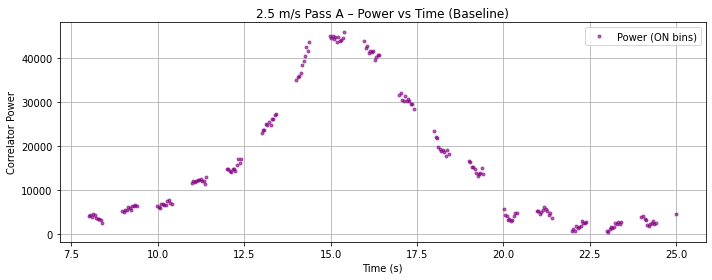

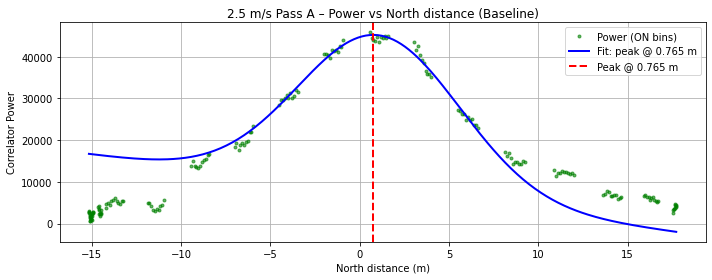

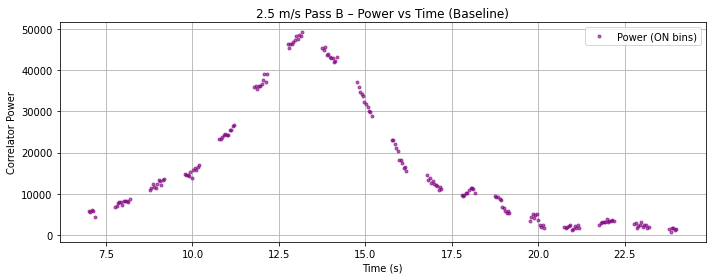

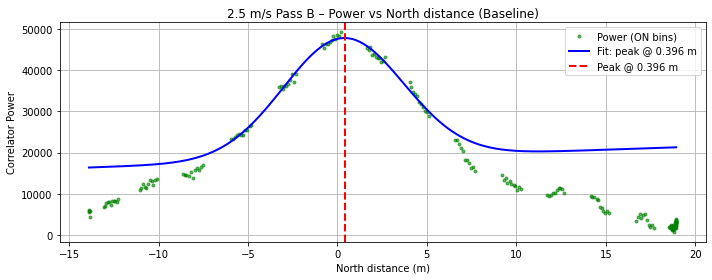

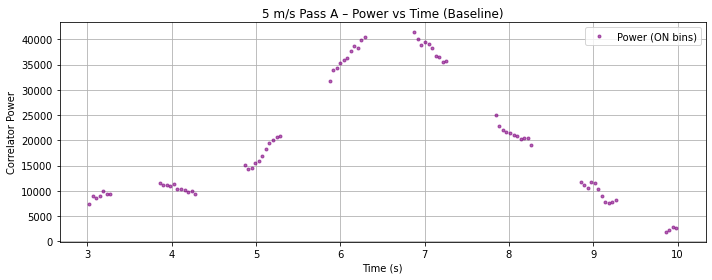

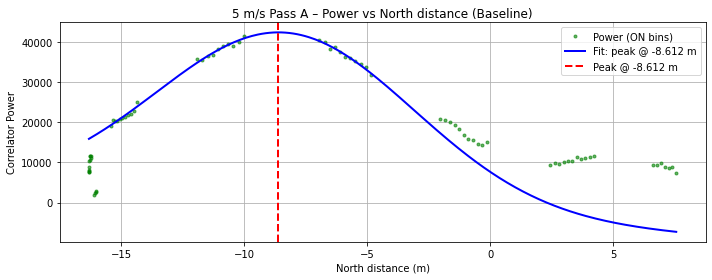

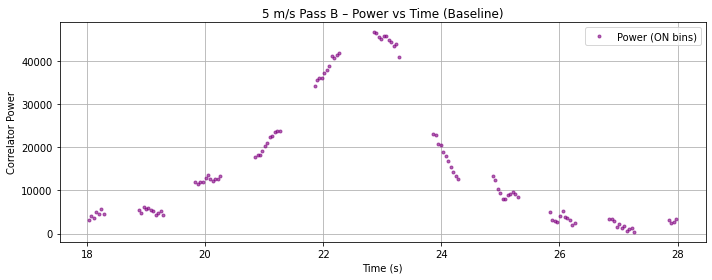

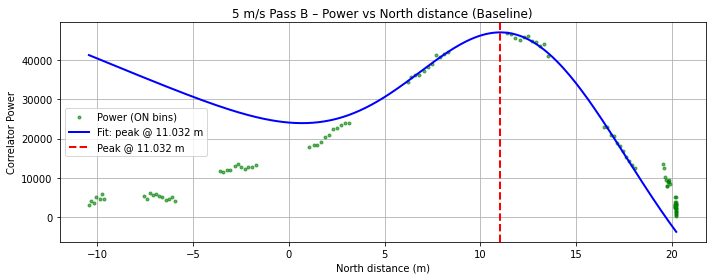

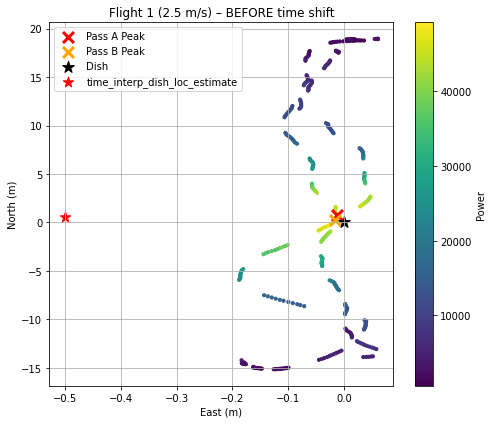

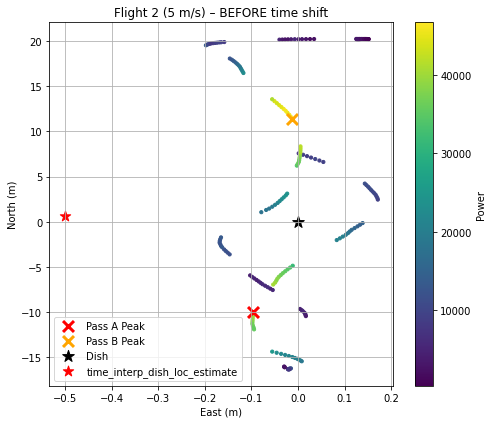

Time offset search:   0%|          | 0/10001 [00:00<?, ?pt/s]

/home/mlc253/anaconda3/lib/python3.8/site-packages/scipy/optimize/_minpack_py.py:906: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',



=== Optimization Summary (Global Time Shift) ===


,Flight,Best Time Shift (s),Pass A Peak (m),Pass B Peak (m),ΔN after shift (m)
0,2.5 m/s,0.076000,0.573537,0.573659,0.000122
1,5 m/s,-1.975000,0.912135,0.913610,0.001476


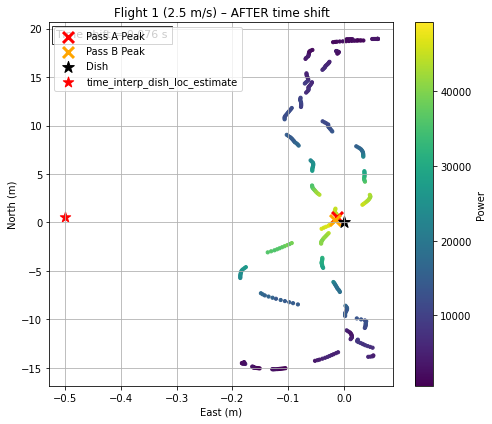

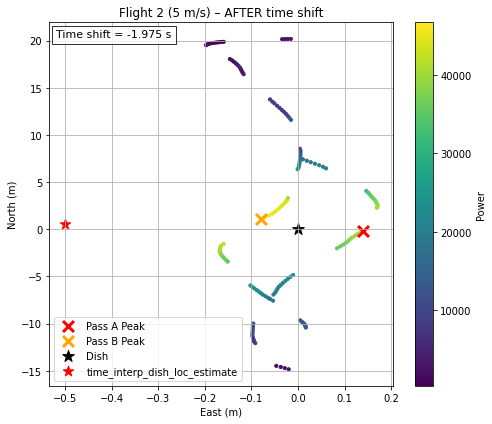

In [8]:
# =========================================================
# Run dish time-shift optimization with full custom parameters
# =========================================================

results = optimize_dish_t(
    # --- Correlator files ---
    corr_dir_or_glob = "/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z",
    dish_loc_baseline = ogsite.origin, #sitedsite.origin, #ogsite.origin,  # (lat, lon, height) in meters
    fbin = 350,                         # frequency bin to use
    corr_index = 8,                      # which correlator channel

    # --- Flight 1 (2.5 m/s) ---
    drone_file_1 = "../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-03-58PM-Flight-Airdata.csv",
    pass1a_range = (99, 102),
    pass1b_range = (101, 104),

    # --- Flight 2 (5 m/s) ---
    drone_file_2 = "../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-04-03PM-Flight-Airdata.csv",
    pass2a_range = (128, 131),
    pass2b_range = (128, 131),

    # --- Plot windows (what you actually want to see) ---
    plotwin_1a = (8, 25),
    plotwin_1b = (7, 24),
    plotwin_2a = (3, 10),
    plotwin_2b = (18, 28),

    # --- Expected peak widths (seconds) per flight ---
    # 2.5 m/s flight is wider (~12 s), 5 m/s is narrower (~8 s)
    peak_width_s_flight1 = 12.0,
    peak_width_s_flight2 = 12,
    peak_width_is_full = True,

    # --- Optimization grid ---
    bound_m = 5,      # search ±1 meter (north-axis shift)
    step_m = 0.001,       # grid step size
    objective = "rms",  # cost function to minimize

    # --- Soft prior (optional) ---
    prior_sigma_m = 10,          # prevents runaway solutions
    prior_center_m = (-1, 1), 

    # --- Table display ---
    table_font_px = 14,
    table_width_pct = 60,

    # --- Plots ---
    show_fit_plots = False,               # baseline plots using original dish
    show_optimized_fit_plots = False,   # legacy toggle
    show_final_fit_plots = True,        # reproduce plots after applying best shift

    # --- Progress bar ---
    show_progress = True,               # uses tqdm if installed
)

In [12]:
y_adjust_2_5mps = np.mean([0.573537,0.573659])
print(y_adjust_2_5mps)


0.573598


In [13]:
y_adjust_5mps = np.mean([0.912135,0.913610])
print(y_adjust_5mps)

0.9128725


In [14]:
#Create a new 2.5m/s and 5m/s specific site class file

import numpy as np

# Path to your file
npz_path = "../metadata/WLC_config_roof.npz"

# Load the file
ogsite = np.load(npz_path, allow_pickle=True)

data = ogsite

print("Keys in the NPZ file:")
print(data.files)
print("-" * 50)

# Loop through all stored arrays
for key in data.files:
    print(f"Key: {key}")
    
    array = data[key]
    
    print(f"Type: {type(array)}")
    print(f"Shape: {array.shape}")
    print(f"Dtype: {array.dtype}")
    
    print("Contents:")
    print(array)
    print("-" * 50)

Keys in the NPZ file:
['name', 'n_dishes', 'n_channels', 'chmap', 'keystrings', 'coords', 'pointings', 'polarizations', 'origin']
--------------------------------------------------
Key: name
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: <U8
Contents:
WLC_DISH
--------------------------------------------------
Key: n_dishes
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: int64
Contents:
1
--------------------------------------------------
Key: n_channels
Type: <class 'numpy.ndarray'>
Shape: ()
Dtype: int64
Contents:
2
--------------------------------------------------
Key: chmap
Type: <class 'numpy.ndarray'>
Shape: (2,)
Dtype: int64
Contents:
[2 3]
--------------------------------------------------
Key: keystrings
Type: <class 'numpy.ndarray'>
Shape: (2,)
Dtype: <U6
Contents:
['Cart_X' 'Cart_Y']
--------------------------------------------------
Key: coords
Type: <class 'numpy.ndarray'>
Shape: (2, 3)
Dtype: float64
Contents:
[[0. 0. 0.]
 [0. 0. 0.]]
-------------------------------------

In [15]:
#just doing a north shift to the ogsite coords: [ 41.31899934 -72.92132019  25.        ]

#2.5 m/s = + 0.573598 ----> 

#5 m/s = + 0.9128725  ----> 

import os
import numpy as np
from pygeodesy.ellipsoidalVincenty import LatLon  # precise WGS84 geodesic

def shift_site_origin_north(npz_path, y_shift_meters, new_filename):
    """
    Create a copy of a site NPZ file with the origin shifted north using pygeodesy.

    Parameters
    ----------
    npz_path : str
        Path to original NPZ file
    y_shift_meters : float
        Northward shift in meters (negative = south)
    new_filename : str
        Name of the new NPZ file (saved in same directory)

    Returns
    -------
    new_path : str
        Full path to the new NPZ file
    """

    # --- Load original ---
    data = np.load(npz_path, allow_pickle=True)
    new_data = {key: data[key] for key in data.files}

    # --- Extract origin ---
    if "origin" not in new_data:
        raise KeyError("No 'origin' key found in NPZ file")

    origin = np.array(new_data["origin"], dtype=float)
    lat, lon, alt = origin

    # --- Create geodesy point ---
    p = LatLon(lat, lon)

    # --- Move north (bearing = 0°) ---
    p_shifted = p.destination(y_shift_meters, 0)  # distance (m), bearing (deg)

    new_origin = np.array([p_shifted.lat, p_shifted.lon, alt])

    # --- Replace origin ---
    new_data["origin"] = new_origin

    # --- Save new file ---
    directory = os.path.dirname(npz_path)
    new_path = os.path.join(directory, new_filename)

    np.savez(new_path, **new_data)

    print("Old origin:", origin)
    print("New origin:", new_origin)
    print("Saved to:", new_path)

    return new_path

In [16]:
shift_site_origin_north(
    npz_path="../metadata/WLC_config_roof.npz",
    y_shift_meters=0.9128725,
    new_filename="WLC_config_roof_5mps.npz"
)

Old origin: [ 41.31899934 -72.92132019  25.        ]
New origin: [ 41.31900756 -72.92132019  25.        ]
Saved to: ../metadata/WLC_config_roof_5mps.npz


'../metadata/WLC_config_roof_5mps.npz'

In [17]:
shift_site_origin_north(
    npz_path="../metadata/WLC_config_roof.npz",
    y_shift_meters=0.573598,
    new_filename="WLC_config_roof_2mps.npz"
)

Old origin: [ 41.31899934 -72.92132019  25.        ]
New origin: [ 41.3190045  -72.92132019  25.        ]
Saved to: ../metadata/WLC_config_roof_2mps.npz


'../metadata/WLC_config_roof_2mps.npz'


=== Baseline Peak Positions ===


,Flight,Pass A Peak (m),Pass B Peak (m),ΔN (B - A) (m)
0,2.5 m/s,0.164693,-0.203656,-0.368349
1,5 m/s,-9.211720,10.431838,19.643557


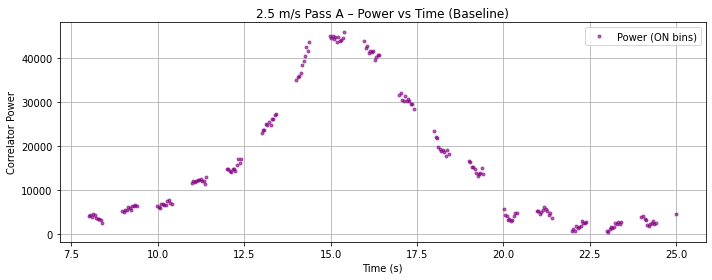

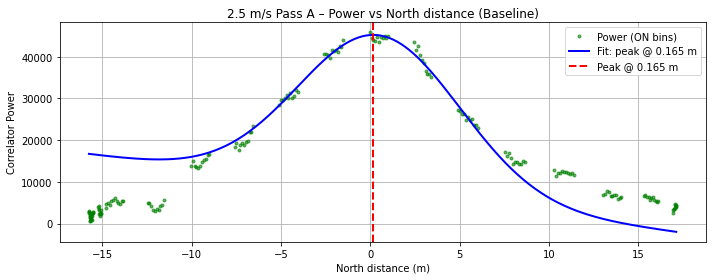

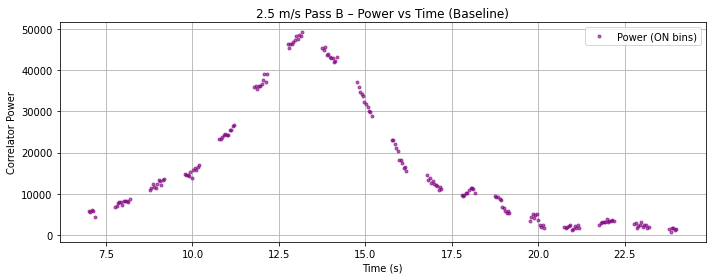

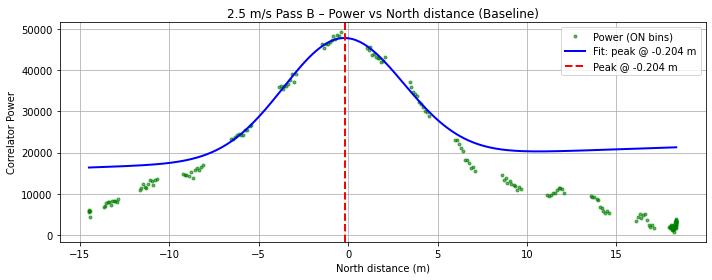

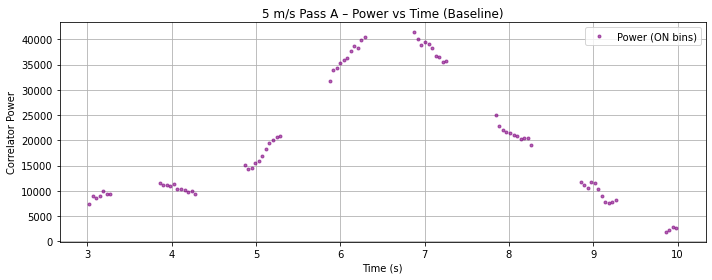

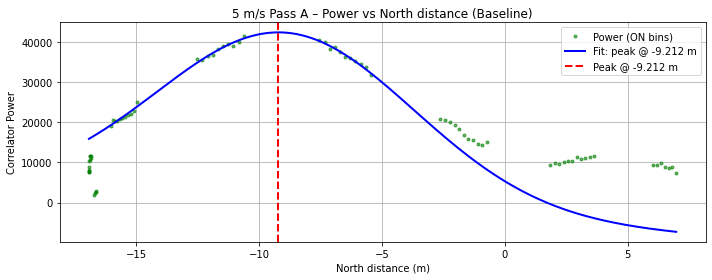

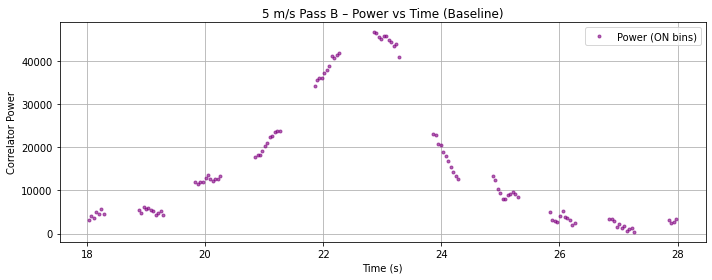

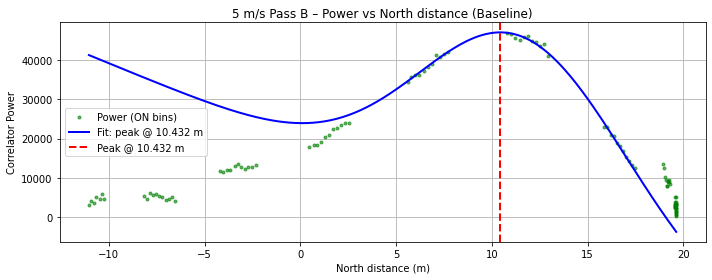

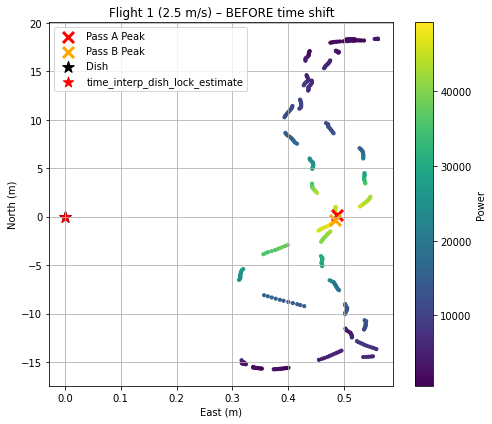

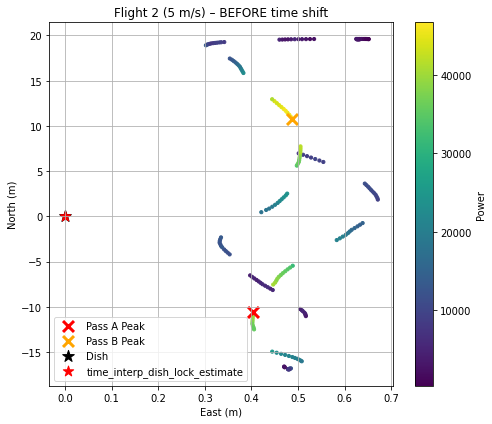

Time offset search:   0%|          | 0/10001 [00:00<?, ?pt/s]


=== Optimization Summary (Global Time Shift) ===


,Flight,Best Time Shift (s),Pass A Peak (m),Pass B Peak (m),ΔN after shift (m)
0,2.5 m/s,0.076000,-0.026468,-0.026346,0.000122
1,5 m/s,-1.975000,0.312130,0.313606,0.001476


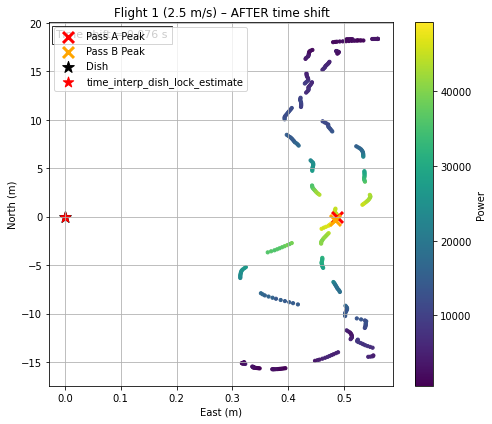

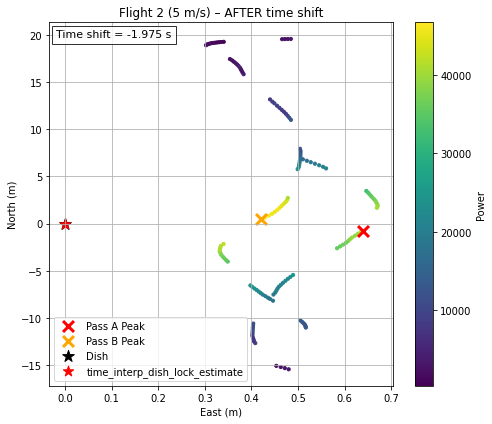

In [20]:
# =========================================================
# Run dish time-shift optimization with full custom parameters
# =========================================================

results = optimize_dish_t(
    # --- Correlator files ---
    corr_dir_or_glob = "/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z",
    dish_loc_baseline = sitedsite.origin, #sitedsite.origin, #ogsite.origin,  # (lat, lon, height) in meters
    fbin = 350,                         # frequency bin to use
    corr_index = 8,                      # which correlator channel

    # --- Flight 1 (2.5 m/s) ---
    drone_file_1 = "../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-03-58PM-Flight-Airdata.csv",
    pass1a_range = (99, 102),
    pass1b_range = (101, 104),

    # --- Flight 2 (5 m/s) ---
    drone_file_2 = "../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-04-03PM-Flight-Airdata.csv",
    pass2a_range = (128, 131),
    pass2b_range = (128, 131),

    # --- Plot windows (what you actually want to see) ---
    plotwin_1a = (8, 25),
    plotwin_1b = (7, 24),
    plotwin_2a = (3, 10),
    plotwin_2b = (18, 28),

    # --- Expected peak widths (seconds) per flight ---
    # 2.5 m/s flight is wider (~12 s), 5 m/s is narrower (~8 s)
    peak_width_s_flight1 = 12.0,
    peak_width_s_flight2 = 12,
    peak_width_is_full = True,

    # --- Optimization grid ---
    bound_m = 5,      # search ±1 meter (north-axis shift)
    step_m = 0.001,       # grid step size
    objective = "rms",  # cost function to minimize

    # --- Soft prior (optional) ---
    prior_sigma_m = 10,          # prevents runaway solutions
    prior_center_m = (-1, 1), 

    # --- Table display ---
    table_font_px = 14,
    table_width_pct = 60,
    
    og_e_shift=0,
    og_n_shift=0,
    

    # --- Plots ---
    show_fit_plots = False,               # baseline plots using original dish
    show_optimized_fit_plots = False,   # legacy toggle
    show_final_fit_plots = True,        # reproduce plots after applying best shift

    # --- Progress bar ---
    show_progress = True,               # uses tqdm if installed
)

In [8]:
# --- progress bar (works in notebooks; falls back cleanly if not installed) ---
try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def plot_single_flight_pass_with_updated_dish(
    corr_dir_or_glob,
    drone_csv,
    *,
    corr_file_range=(0, -1),
    fbin=300,
    corr_index=8,
    dish_loc_updated=None,

    plotwin=(0.0, None),
    fit_peak_width_s=8.0,
    peak_width_is_full=True,

    period_us=0.9999e6,
    duty_us=0.5e6,
    minmaxpercents=(0.0001, 100),

    # NEW/CHANGED:
    # Instead of scanning 3 channels (channel_for_alignment + [0,1,2]),
    # we align using ONE channel only. Default: use corr_index (your calling cell).
    align_channel=7,  # if None -> corr_index

    title_prefix="Single pass",
    show_progress=True,
):
    """
    Faster version:
      - Pulse alignment is computed using exactly ONE correlator channel (align_channel),
        rather than looping over 3 channels.
      - Everything else is unchanged.
    """

    # ------------------------------
    # models
    # ------------------------------
    def quad_vertex(t, a, t0, c):
        return a * (t - t0) ** 2 + c

    def gauss_linear(t, A, mu, sigma, m, b):
        return A * np.exp(-(t - mu) ** 2 / (2 * sigma ** 2)) + (m * t + b)

    def halfwidth_from_peakwidth(w):
        w = float(w)
        return 0.5 * w if peak_width_is_full else w

    # ------------------------------
    # correlator helpers
    # ------------------------------
    def list_corr_files(path):
        if os.path.isdir(path):
            return sorted(os.path.join(path, f) for f in os.listdir(path) if ".lock" not in f)
        return sorted(f for f in glob.glob(path) if ".lock" not in f)

    def read_corr_range(files, s, e):
        sel = files[s:] if e == -1 else files[s:e]
        if len(sel) == 0:
            raise ValueError(f"No correlator files in range [{s}:{e}]")

        use_pbar = (tqdm is not None) and bool(show_progress)
        iterator = tqdm(sel, desc="Reading corr files", unit="file") if use_pbar else sel

        vis, time_arr = None, None
        for k, fp in enumerate(iterator):
            with h5py.File(fp, "r") as f:
                idx = f["index_map"]
                if k == 0:
                    vis = f["vis"][:]
                    time_arr = idx["time"][:]
                else:
                    vis = np.append(vis, f["vis"][:], axis=0)
                    time_arr = np.append(time_arr, idx["time"][:])

        class Corr: pass
        c = Corr()
        c.vis = vis
        c.time = time_arr
        return c

    # ------------------------------
    # robust drone loader
    # ------------------------------
    def load_drone(csv):
        df = pd.read_csv(csv, low_memory=False)

        if "datetime(utc)" in df.columns and "time(millisecond)" in df.columns:
            t0 = pd.to_datetime(df["datetime(utc)"], utc=True).iloc[0]
            times = np.array([(t0 + datetime.timedelta(milliseconds=x)).timestamp()
                              for x in df["time(millisecond)"]], dtype=float)
        elif "GPS:dateTimeStamp" in df.columns:
            times = pd.to_datetime(df["GPS:dateTimeStamp"], utc=True)\
                        .map(lambda t: t.timestamp()).values.astype(float)
        else:
            raise KeyError(
                "No recognizable time columns in drone file. "
                "Expected ('datetime(utc)' + 'time(millisecond)') or 'GPS:dateTimeStamp'."
            )

        candidates = [
            ("RTKdata:Lat_P", "RTKdata:Lon_P", "RTKdata:Hmsl_P"),
            ("GPS(0):Lat", "GPS(0):Long", "GPS(0):heightMSL"),
            ("GPS:Lat", "GPS:Long", "GPS:heightMSL"),
            ("GPS:Lat", "GPS:Lon", "GPS:heightMSL"),
            ("latitude", "longitude", "altitude(meters)"),
            ("latitude", "longitude", "altitude(feet)"),
        ]

        lat = lon = alt = None
        alt_is_feet = False
        for a, b, c in candidates:
            if a in df.columns and b in df.columns and c in df.columns:
                lat = df[a].values
                lon = df[b].values
                alt = df[c].values
                alt_is_feet = (c == "altitude(feet)")
                break

        if lat is None:
            cols = list(df.columns)
            lat_like = [x for x in cols if "lat" in x.lower()]
            lon_like = [x for x in cols if "lon" in x.lower() or "long" in x.lower()]
            alt_like = [x for x in cols if "alt" in x.lower() or "hmsl" in x.lower() or "height" in x.lower()]
            raise KeyError(
                "Could not find recognizable lat/lon/alt columns in drone CSV.\n"
                f"Lat-like columns: {lat_like[:15]}\n"
                f"Lon/Long-like columns: {lon_like[:15]}\n"
                f"Alt/Height-like columns: {alt_like[:15]}"
            )

        lat = np.asarray(lat, dtype=float)
        lon = np.asarray(lon, dtype=float)
        alt = np.asarray(alt, dtype=float)
        if alt_is_feet:
            alt = alt * 0.3048

        valid = np.isfinite(times) & np.isfinite(lat) & np.isfinite(lon) & np.isfinite(alt)
        if not np.any(valid):
            raise ValueError("No valid (finite) time/lat/lon/alt rows found after parsing drone CSV.")

        return times[valid], lat[valid], lon[valid], alt[valid]

    # ------------------------------
    # lat/lon/alt -> ENU (using UPDATED dish)
    # ------------------------------
    def drone_to_enu(lat, lon, alt, dish):
        use_pbar = (tqdm is not None) and bool(show_progress)
        iterator = tqdm(range(len(lat)), desc="Drone → ENU", unit="pt") if use_pbar else range(len(lat))

        origin = pygeodesy.EcefCartesian(latlonh0=dish[0], lon0=dish[1], height0=dish[2])
        out = np.zeros((len(lat), 3))
        for i in iterator:
            p = pygeodesy.ellipsoidalNvector.LatLon(lat[i], lon[i], height=alt[i])
            out[i] = origin.forward(p).toVector()
        return out

    # ------------------------------
    # Will-style pulse extraction (FAST: ONE channel)
    # ------------------------------
    def extract_source_pulses_like_will_one_channel(corr, *, t_bounds=(0, -1), align_chan=0):
        if align_chan < 0 or align_chan >= corr.vis.shape[2]:
            raise IndexError(f"align_channel={align_chan} out of bounds for corr.vis {corr.vis.shape}")

        delta_time = np.diff(corr.time["irigb_time"])[1] * 1e-9
        concat_duration = int(np.ceil(delta_time * len(corr.vis)))

        time_s, time_dt, switch = tu.Pulsed_Data_Waveform(
            total_duration=concat_duration,
            period=period_us,
            duty_cycle_on=duty_us,
        )

        num_bins = corr.vis.shape[0]
        time_bin_width = np.diff(corr.time["irigb_time"])[1] * 1e-9
        t_full = np.arange(num_bins) * time_bin_width

        t_offset_dist = np.arange(-1.0 * period_us * 1e-6, 0.0, 0.001)

        tb0, tb1 = t_bounds
        t_hi = t_full[-1] if tb1 == -1 else t_full[tb1]
        t_lo = t_full[tb0]
        sniparr = np.where(time_s[np.where(time_s <= t_hi)[0]] >= t_lo)[0]

        minsubdata = corr.vis[:, fbin, align_chan] - np.percentile(corr.vis[:, fbin, align_chan], minmaxpercents[0])
        normminsubdata = minsubdata / np.percentile(minsubdata, minmaxpercents[1])
        clipnormminsubdata = np.clip(normminsubdata, 0, 1)

        stepped_func = interp1d(t_full, clipnormminsubdata, kind="previous", fill_value="extrapolate")
        t_restrict = np.intersect1d(
            np.arange(len(time_s))[~np.isnan(stepped_func(time_s))],
            sniparr
        )

        Pr = np.NaN * np.ones(t_offset_dist.shape[0])

        use_pbar = (tqdm is not None) and bool(show_progress)
        off_iter = enumerate(t_offset_dist)
        if use_pbar:
            # NOTE: don't wrap with list() here; keep it streaming
            off_iter = tqdm(off_iter, total=len(t_offset_dist), desc=f"Pulse align offsets (ch {align_chan})",
                            unit="off", leave=False)

        for j, t_offset in off_iter:
            shiftedswitch = np.interp(time_s, time_s + t_offset, switch)
            try:
                Pr[j] = pearsonr(
                    stepped_func(time_s[t_restrict]).real,
                    shiftedswitch[t_restrict]
                )[0]
            except ValueError:
                Pr[j] = np.nan

        if not np.isfinite(np.nanmax(Pr)):
            raise ValueError("Pulse alignment failed: Pearson R is all-NaN on this channel.")

        maxPrind = int(np.nanargmax(Pr))
        t_delta_pulse = float(t_offset_dist[maxPrind])

        t_for_interp_out = np.arange(num_bins) * time_bin_width
        t_for_interp_in = np.array([m.total_seconds() for m in time_dt])
        switch_interp_f = np.interp(t_for_interp_out, t_for_interp_in + t_delta_pulse, switch)

        inds_span = np.union1d(
            list(set(np.where(np.diff(np.sign(switch_interp_f)))[0])),
            np.intersect1d(np.where(1 > switch_interp_f), np.where(switch_interp_f > 0))
        ).tolist()
        inds_span = np.asarray(sorted(set(inds_span)), dtype=int)

        inds_on = np.asarray(sorted(list(set(np.where(switch_interp_f == 1)[0]) - set(inds_span))), dtype=int)
        inds_off = np.asarray(sorted(list(set(np.where(switch_interp_f == 0)[0]) - set(inds_span))), dtype=int)

        return inds_on, inds_off, inds_span, t_delta_pulse

    # ------------------------------
    # resolve updated dish
    # ------------------------------
    if dish_loc_updated is None:
        if "results" in globals() and isinstance(results, dict) and "new_dish_latlon" in results:
            dish_loc_updated = results["new_dish_latlon"]
        else:
            raise ValueError("dish_loc_updated=None and no global `results['new_dish_latlon']` found.")

    # resolve align channel
    if align_channel is None:
        align_channel = int(corr_index)

    # ------------------------------
    # load drone + compute ENU w.r.t UPDATED dish
    # ------------------------------
    drone_times, lat, lon, alt = load_drone(drone_csv)
    enu = drone_to_enu(lat, lon, alt, dish_loc_updated)

    # ------------------------------
    # load correlator range
    # ------------------------------
    files = list_corr_files(corr_dir_or_glob)
    if len(files) == 0:
        raise ValueError("No correlator files found from corr_dir_or_glob.")

    s, e = corr_file_range
    corr = read_corr_range(files, s, e)

    inds_on, inds_off, inds_span, t_delta_pulse = extract_source_pulses_like_will_one_channel(
        corr, t_bounds=(0, -1), align_chan=align_channel
    )
    if len(inds_on) < 8:
        raise ValueError(f"Too few ON bins for corr_file_range {corr_file_range}: {len(inds_on)}")

    corr_epoch = np.array([float(t[-1]) for t in corr.time], dtype=float)

    times_dt_all = [datetime.datetime.utcfromtimestamp(t[-1]) for t in corr.time]
    times_dt_sel = [times_dt_all[i] for i in inds_on]
    t_on = np.array([(tt - times_dt_sel[0]).total_seconds() for tt in times_dt_sel], dtype=float)

    mag_all = np.abs(corr.vis)[:, fbin, corr_index]
    mag_on = mag_all[inds_on]

    E_all = np.interp(corr_epoch, drone_times, enu[:, 0])
    N_all = np.interp(corr_epoch, drone_times, enu[:, 1])
    U_all = np.interp(corr_epoch, drone_times, enu[:, 2])

    E_on = E_all[inds_on]
    N_on = N_all[inds_on]
    U_on = U_all[inds_on]

    # ------------------------------
    # apply plot window
    # ------------------------------
    p0 = float(plotwin[0]) if plotwin[0] is not None else float(np.nanmin(t_on))
    p1 = float(plotwin[1]) if plotwin[1] is not None else float(np.nanmax(t_on))
    m_plot = (t_on >= p0) & (t_on <= p1)

    t_plot = t_on[m_plot]
    mag_plot = mag_on[m_plot]
    E_plot = E_on[m_plot]
    N_plot = N_on[m_plot]
    U_plot = U_on[m_plot]

    if len(t_plot) < 12:
        raise ValueError(f"Plot window {plotwin} leaves too few ON samples: {len(t_plot)}")

    d_plot = np.sqrt(E_plot**2 + N_plot**2 + U_plot**2)

    # ------------------------------
    # fits
    # ------------------------------
    halfw = halfwidth_from_peakwidth(fit_peak_width_s)

    i_min = int(np.argmin(d_plot))
    t0_guess = float(t_plot[i_min])
    md = np.abs(t_plot - t0_guess) <= halfw
    if md.sum() < 8:
        keep = np.argsort(np.abs(t_plot - t0_guess))[:max(8, min(20, len(t_plot)))]
        md = np.isin(np.arange(len(t_plot)), keep)

    t_dist = t_plot[md]
    y_dist = d_plot[md]

    popt_d, pcov_d = curve_fit(
        quad_vertex, t_dist, y_dist,
        p0=[1.0, t0_guess, float(np.min(y_dist))],
        maxfev=20000
    )
    t0_d = float(popt_d[1])
    sig_t0 = float(np.sqrt(pcov_d[1, 1])) if np.isfinite(pcov_d[1, 1]) else np.nan

    i_pk = int(np.argmax(mag_plot))
    mu_guess = float(t_plot[i_pk])
    mp = np.abs(t_plot - mu_guess) <= halfw
    if mp.sum() < 10:
        keep = np.argsort(np.abs(t_plot - mu_guess))[:max(10, min(25, len(t_plot)))]
        mp = np.isin(np.arange(len(t_plot)), keep)

    t_pow = t_plot[mp]
    y_pow = mag_plot[mp]

    n_edge = max(5, int(0.2 * len(t_pow)))
    t_edges = np.concatenate([t_pow[:n_edge], t_pow[-n_edge:]])
    y_edges = np.concatenate([y_pow[:n_edge], y_pow[-n_edge:]])
    m_guess, b_guess = np.polyfit(t_edges, y_edges, 1)

    A_guess = float(np.max(y_pow) - (m_guess * mu_guess + b_guess))
    sigma_guess = max(1e-3, 0.35 * halfw)

    popt_p, pcov_p = curve_fit(
        gauss_linear, t_pow, y_pow,
        p0=[max(A_guess, 1e-12), mu_guess, sigma_guess, m_guess, b_guess],
        maxfev=30000
    )
    mu_p = float(popt_p[1])
    sig_mu = float(np.sqrt(pcov_p[1, 1])) if np.isfinite(pcov_p[1, 1]) else np.nan

    delta_tau = float(mu_p - t0_d)
    sig_dt = float(np.sqrt(sig_mu**2 + sig_t0**2)) if (np.isfinite(sig_mu) and np.isfinite(sig_t0)) else np.nan

    # ------------------------------
    # plots
    # ------------------------------
    t_fit = np.linspace(p0, p1, 1200)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax1.plot(t_plot, d_plot, ".", color="black", label="Distance (updated dish)")
    ax1.plot(t_fit, quad_vertex(t_fit, *popt_d), "-", color="red", linewidth=2, label="Quadratic fit")
    ax1.axvline(t0_d, color="red", linestyle="--", linewidth=2, label=f"min @ {t0_d:.3f}s")
    ax1.set_ylabel("Distance (m)")
    ax1.set_title(
        f"{title_prefix}  |  corr[{s}:{e}]  fbin={fbin}  corr_index={corr_index}\n"
        f"updated dish: lat={dish_loc_updated[0]:.10f}, lon={dish_loc_updated[1]:.10f}, alt={dish_loc_updated[2]:.3f} m\n"
        f"pulse align channel: {align_channel}"
    )
    ax1.grid(True)
    ax1.legend()

    ax2.plot(t_plot, mag_plot, ".", color="purple", alpha=0.6, label="Power magnitude (ON bins)")
    ax2.plot(t_fit, gauss_linear(t_fit, *popt_p), "-", color="blue", linewidth=2, label="Gaussian+linear fit")
    ax2.axvline(mu_p, color="blue", linestyle="--", linewidth=2, label=f"peak @ {mu_p:.3f}s")
    ax2.set_xlabel("Time since first ON sample (s)")
    ax2.set_ylabel("|vis|")
    ax2.grid(True)
    ax2.legend()

    ax2.set_xlim(p0, p1)
    plt.tight_layout()
    plt.show()

    print("\n=== Δτ result (single pass) ===")
    print(f"Distance min time  t0_d : {t0_d:.6f} s   (σ={sig_t0:.6f} s)")
    print(f"Power peak time    mu_p : {mu_p:.6f} s   (σ={sig_mu:.6f} s)")
    print(f"Δτ = mu_p - t0_d        : {delta_tau:.6f} s   (σ={sig_dt:.6f} s)")
    #print(f"Pulse alignment tΔ (from Will-style extraction): {t_delta_pulse:.6f} s")
    print(f"ON bins: {len(inds_on)}   OFF bins: {len(inds_off)}   SPAN bins: {len(inds_span)}")

    return {
        "dish_loc_used": dish_loc_updated,
        "corr_range": (s, e),
        "plotwin": (p0, p1),
        "fit_halfwidth_s": halfw,
        "t0_d": t0_d,
        "sig_t0": sig_t0,
        "mu_p": mu_p,
        "sig_mu": sig_mu,
        "delta_tau": delta_tau,
        "sig_delta_tau": sig_dt,
        "popt_d": popt_d,
        "popt_p": popt_p,
        "meta": {
            "t_delta_pulse": float(t_delta_pulse),
            "pulse_align_channel": int(align_channel),
            "ON": int(len(inds_on)),
            "OFF": int(len(inds_off)),
            "SPAN": int(len(inds_span)),
        },
    }


Drone → ENU:   0%|          | 0/5200 [00:00<?, ?pt/s]

Reading corr files:   0%|          | 0/38 [00:00<?, ?file/s]

Pulse align offsets (ch 7):   0%|          | 0/1000 [00:00<?, ?off/s]

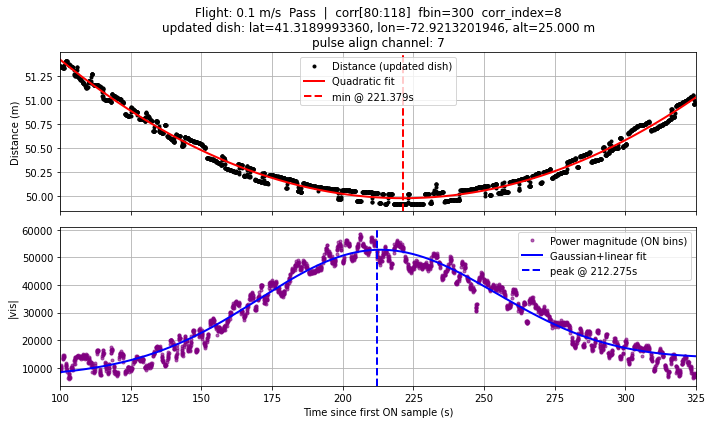


=== Δτ result (single pass) ===
Distance min time  t0_d : 221.379315 s   (σ=0.093130 s)
Power peak time    mu_p : 212.275058 s   (σ=0.234454 s)
Δτ = mu_p - t0_d        : -9.104257 s   (σ=0.252273 s)
ON bins: 4455   OFF bins: 4445   SPAN bins: 828


In [10]:
# ============================
# Example call (edit these)
# ============================
single_pass = plot_single_flight_pass_with_updated_dish(
    corr_dir_or_glob='/hirax/DNS_freespace/yale_visit_april_2025/manual_and_0.1_pass',
    drone_csv="../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-03-27PM-Flight-Airdata.csv",

    corr_file_range=(80, 118),   # start, stop (stop=-1 means to end)
    fbin=300,
    corr_index=8,

    # uses results["new_dish_latlon"] automatically if you leave dish_loc_updated=None
    dish_loc_updated=ogsite.origin, #None,

    # plotting window (what you SEE)
    plotwin=(100, 325),

    # fitting width (what the fits use)
    fit_peak_width_s=200.0,
    peak_width_is_full=True,

    title_prefix="Flight: 0.1 m/s  Pass",
)


Drone → ENU:   0%|          | 0/3406 [00:00<?, ?pt/s]

Reading corr files:   0%|          | 0/4 [00:00<?, ?file/s]

Pulse align offsets (ch 7):   0%|          | 0/1000 [00:00<?, ?off/s]

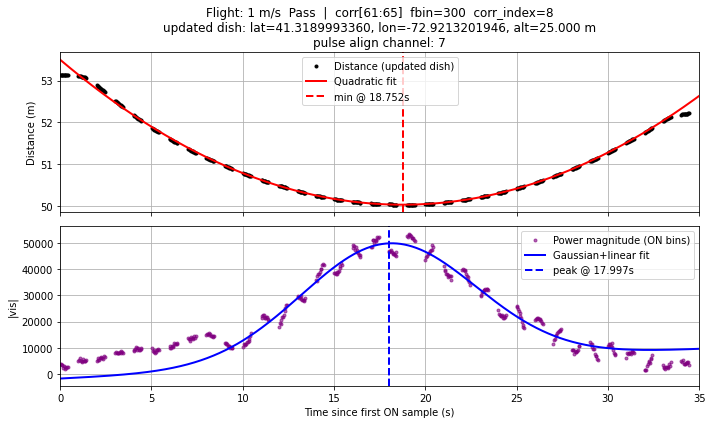


=== Δτ result (single pass) ===
Distance min time  t0_d : 18.751898 s   (σ=0.001729 s)
Power peak time    mu_p : 17.996604 s   (σ=0.087083 s)
Δτ = mu_p - t0_d        : -0.755294 s   (σ=0.087100 s)
ON bins: 475   OFF bins: 463   SPAN bins: 86


In [11]:
# ============================
# Example call (edit these)
# ============================
single_pass = plot_single_flight_pass_with_updated_dish(
    corr_dir_or_glob='/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z',
    drone_csv="../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-03-50PM-Flight-Airdata.csv",

    corr_file_range=(61, 65),   # start, stop (stop=-1 means to end)
    fbin=300,
    corr_index=8,

    # uses results["new_dish_latlon"] automatically if you leave dish_loc_updated=None
    dish_loc_updated=ogsite.origin, #None,

    # plotting window (what you SEE)
    plotwin=(0, 35),

    # fitting width (what the fits use)
    fit_peak_width_s=20.0,
    peak_width_is_full=True,

    title_prefix="Flight: 1 m/s  Pass",
)


Drone → ENU:   0%|          | 0/1816 [00:00<?, ?pt/s]

Reading corr files:   0%|          | 0/3 [00:00<?, ?file/s]

Pulse align offsets (ch 7):   0%|          | 0/1000 [00:00<?, ?off/s]

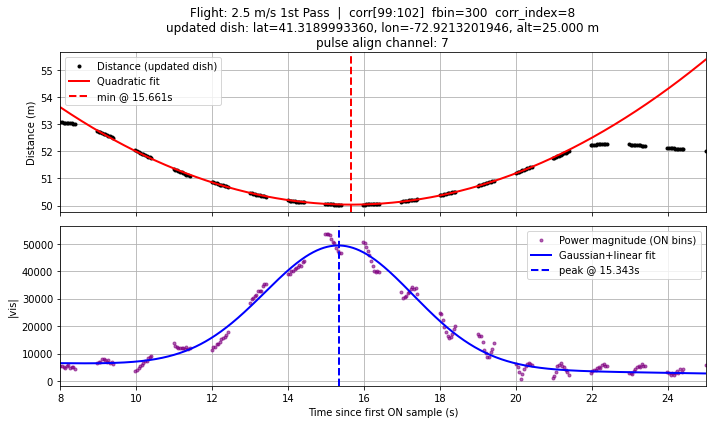


=== Δτ result (single pass) ===
Distance min time  t0_d : 15.660521 s   (σ=0.003796 s)
Power peak time    mu_p : 15.343059 s   (σ=0.033244 s)
Δτ = mu_p - t0_d        : -0.317463 s   (σ=0.033460 s)
ON bins: 349   OFF bins: 355   SPAN bins: 64


In [12]:
# ============================
# Example call (edit these)
# ============================
single_pass = plot_single_flight_pass_with_updated_dish(
    corr_dir_or_glob='/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z',
    drone_csv="../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-03-58PM-Flight-Airdata.csv",

    corr_file_range=(99, 102),   # start, stop (stop=-1 means to end)
    fbin=300,
    corr_index=8,

    # uses results["new_dish_latlon"] automatically if you leave dish_loc_updated=None
    dish_loc_updated=ogsite.origin,

    # plotting window (what you SEE)
    plotwin=(8, 25),

    # fitting width (what the fits use)
    fit_peak_width_s=12.0,
    peak_width_is_full=True,

    title_prefix="Flight: 2.5 m/s 1st Pass",
)


Drone → ENU:   0%|          | 0/1816 [00:00<?, ?pt/s]

Reading corr files:   0%|          | 0/3 [00:00<?, ?file/s]

Pulse align offsets (ch 7):   0%|          | 0/1000 [00:00<?, ?off/s]

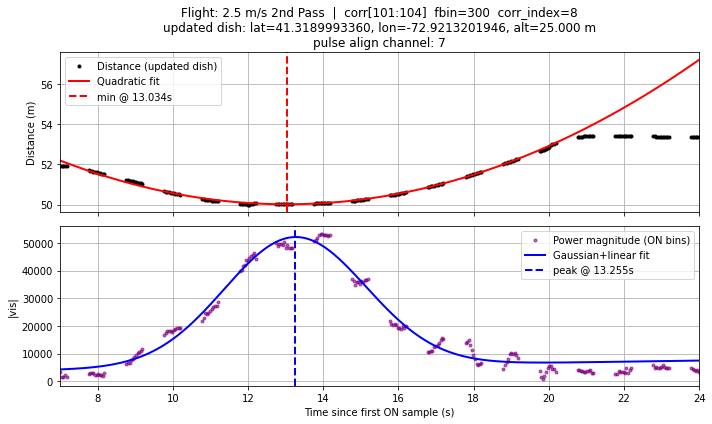


=== Δτ result (single pass) ===
Distance min time  t0_d : 13.033594 s   (σ=0.017301 s)
Power peak time    mu_p : 13.254832 s   (σ=0.033093 s)
Δτ = mu_p - t0_d        : 0.221237 s   (σ=0.037342 s)
ON bins: 355   OFF bins: 349   SPAN bins: 64


In [13]:
# ============================
# Example call (edit these)
# ============================
single_pass = plot_single_flight_pass_with_updated_dish(
    corr_dir_or_glob='/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z',
    drone_csv="../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-03-58PM-Flight-Airdata.csv",

    corr_file_range=(101, 104),   # start, stop (stop=-1 means to end)
    fbin=300,
    corr_index=8,

    # uses results["new_dish_latlon"] automatically if you leave dish_loc_updated=None
    dish_loc_updated=ogsite.origin,

    # plotting window (what you SEE)
    plotwin=(7, 24),

    # fitting width (what the fits use)
    fit_peak_width_s=12.0,
    peak_width_is_full=True,

    title_prefix="Flight: 2.5 m/s 2nd Pass",
)


Drone → ENU:   0%|          | 0/1645 [00:00<?, ?pt/s]

Reading corr files:   0%|          | 0/3 [00:00<?, ?file/s]

Pulse align offsets (ch 7):   0%|          | 0/1000 [00:00<?, ?off/s]

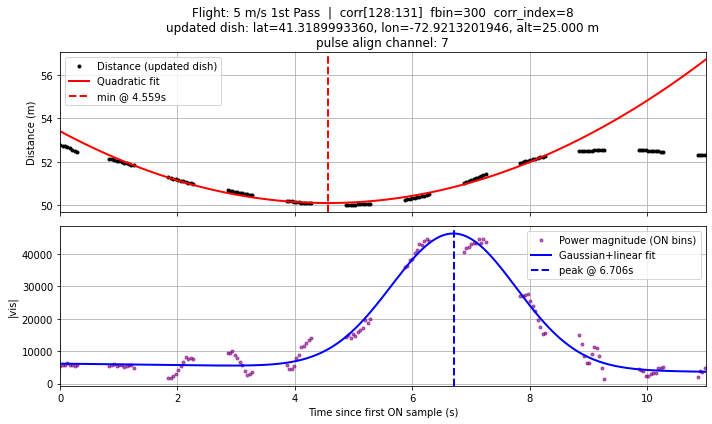


=== Δτ result (single pass) ===
Distance min time  t0_d : 4.558531 s   (σ=0.015552 s)
Power peak time    mu_p : 6.706412 s   (σ=0.021682 s)
Δτ = mu_p - t0_d        : 2.147881 s   (σ=0.026683 s)
ON bins: 356   OFF bins: 347   SPAN bins: 65


In [14]:
# ============================
# Example call (edit these)
# ============================
single_pass = plot_single_flight_pass_with_updated_dish(
    corr_dir_or_glob='/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z',
    drone_csv="../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-04-03PM-Flight-Airdata.csv",

    corr_file_range=(128, 131),   # start, stop (stop=-1 means to end)
    fbin=300,
    corr_index=8,

    # uses results["new_dish_latlon"] automatically if you leave dish_loc_updated=None
    dish_loc_updated=ogsite.origin,

    # plotting window (what you SEE)
    plotwin=(0, 11),

    # fitting width (what the fits use)
    fit_peak_width_s=8.0,
    peak_width_is_full=True,

    title_prefix="Flight: 5 m/s 1st Pass",
)


Drone → ENU:   0%|          | 0/1645 [00:00<?, ?pt/s]

Reading corr files:   0%|          | 0/3 [00:00<?, ?file/s]

Pulse align offsets (ch 7):   0%|          | 0/1000 [00:00<?, ?off/s]

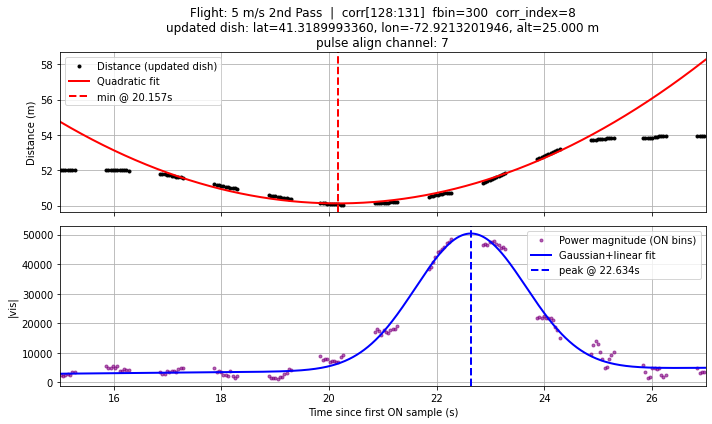


=== Δτ result (single pass) ===
Distance min time  t0_d : 20.157292 s   (σ=0.021043 s)
Power peak time    mu_p : 22.633944 s   (σ=0.017562 s)
Δτ = mu_p - t0_d        : 2.476653 s   (σ=0.027408 s)
ON bins: 356   OFF bins: 347   SPAN bins: 65


In [15]:
# ============================
# Example call (edit these)
# ============================
single_pass = plot_single_flight_pass_with_updated_dish(
    corr_dir_or_glob='/hirax/DNS_freespace/yale_visit_april_2025/20250412T194037Z_WVUc52/corr/20250412T194134Z',
    drone_csv="../../yale_visit_april_2025_results/drone_flight_records/Apr-12th-2025-04-03PM-Flight-Airdata.csv",

    corr_file_range=(128, 131),   # start, stop (stop=-1 means to end)
    fbin=300,
    corr_index=8,

    # uses results["new_dish_latlon"] automatically if you leave dish_loc_updated=None
    dish_loc_updated=ogsite.origin,

    # plotting window (what you SEE)
    plotwin=(15, 27),

    # fitting width (what the fits use)
    fit_peak_width_s=8.0,
    peak_width_is_full=True,

    title_prefix="Flight: 5 m/s 2nd Pass",
)


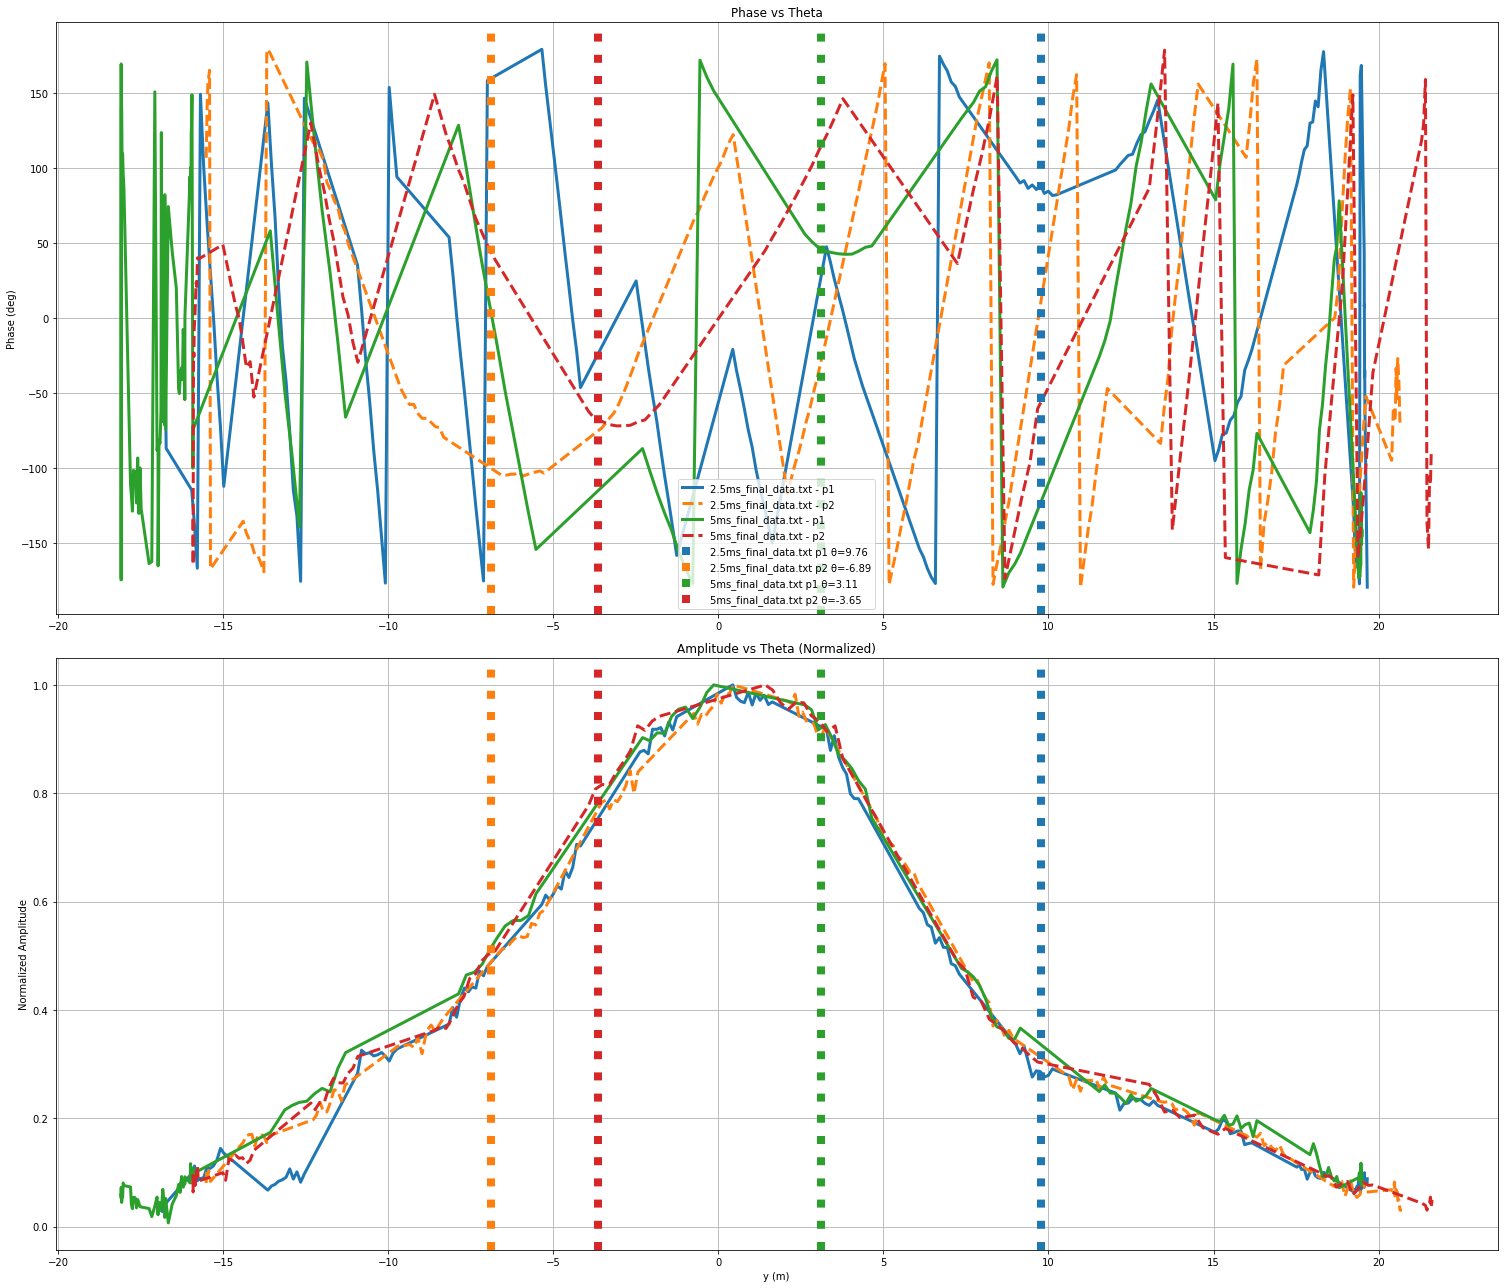

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def load_txt_data(filename):
    data = {}
    current_key = None
    current_vals = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            if line.startswith("#"):
                if current_key is not None:
                    data[current_key] = np.array(current_vals).flatten()
                current_key = line[1:].strip()
                current_vals = []
            else:
                nums = [float(x) for x in line.split()]
                current_vals.extend(nums)

        if current_key is not None:
            data[current_key] = np.array(current_vals).flatten()

    return data


# ----------------------------------------
# File list
# ----------------------------------------
files = ["2.5ms_final_data.txt", "5ms_final_data.txt"]

# ----------------------------------------
# USER CONTROL: vertical line positions
# (one per pass, in plotting order)
# ----------------------------------------
theta_lines = [
    9.761901702477783,   # file1 pass1
    -6.892563798218031,    # file1 pass2
  3.1140401587656976,   # file2 pass1
    -3.6527521905722073,     # file2 pass2
]

# ----------------------------------------
# Create subplots
# ----------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7*3,6*3))

line_colors = []   # store colors for vertical lines
labels_for_lines = []
line_counter = 0

for fname in files:
    data = load_txt_data(fname)

    theta1 = data["theta1"]
    phase1 = data["phase1"]
    amp1   = data["amp1"]

    theta2 = data["theta2"]
    phase2 = data["phase2"]
    amp2   = data["amp2"]

    # ---- sort ----
    idx1 = np.argsort(theta1)
    theta1, phase1, amp1 = theta1[idx1], phase1[idx1], amp1[idx1]

    idx2 = np.argsort(theta2)
    theta2, phase2, amp2 = theta2[idx2], phase2[idx2], amp2[idx2]

    # ---- normalize ----
    amp1 = amp1 / np.max(amp1)
    amp2 = amp2 / np.max(amp2)

    # ---- plot (thicker lines) ----
    l1, = ax1.plot(theta1, phase1, linewidth=3, label=f"{fname} - p1")
    l2, = ax1.plot(theta2, phase2, linestyle='--', linewidth=3, label=f"{fname} - p2")

    ax2.plot(theta1, amp1, linewidth=3)
    ax2.plot(theta2, amp2, linestyle='--', linewidth=3)

    # ---- store colors for vertical lines ----
    line_colors.append(l1.get_color())
    labels_for_lines.append(f"{fname} p1")

    line_colors.append(l2.get_color())
    labels_for_lines.append(f"{fname} p2")


# ----------------------------------------
# Add vertical lines (same color, both plots)
# ----------------------------------------
for i, theta_v in enumerate(theta_lines):
    color = line_colors[i]
    label = f"{labels_for_lines[i]} θ={theta_v:.2f}"

    ax1.axvline(theta_v, color=color, linestyle=':', linewidth=8, label=label)
    ax2.axvline(theta_v, color=color, linestyle=':', linewidth=8)


# ----------------------------------------
# Labels
# ----------------------------------------
ax1.set_ylabel("Phase (deg)")
ax1.set_title("Phase vs Theta")
ax1.grid()
ax1.legend(fontsize=10)

ax2.set_xlabel("y (m)")
ax2.set_ylabel("Normalized Amplitude")
ax2.set_title("Amplitude vs Theta (Normalized)")
ax2.grid()

plt.tight_layout()
plt.show()

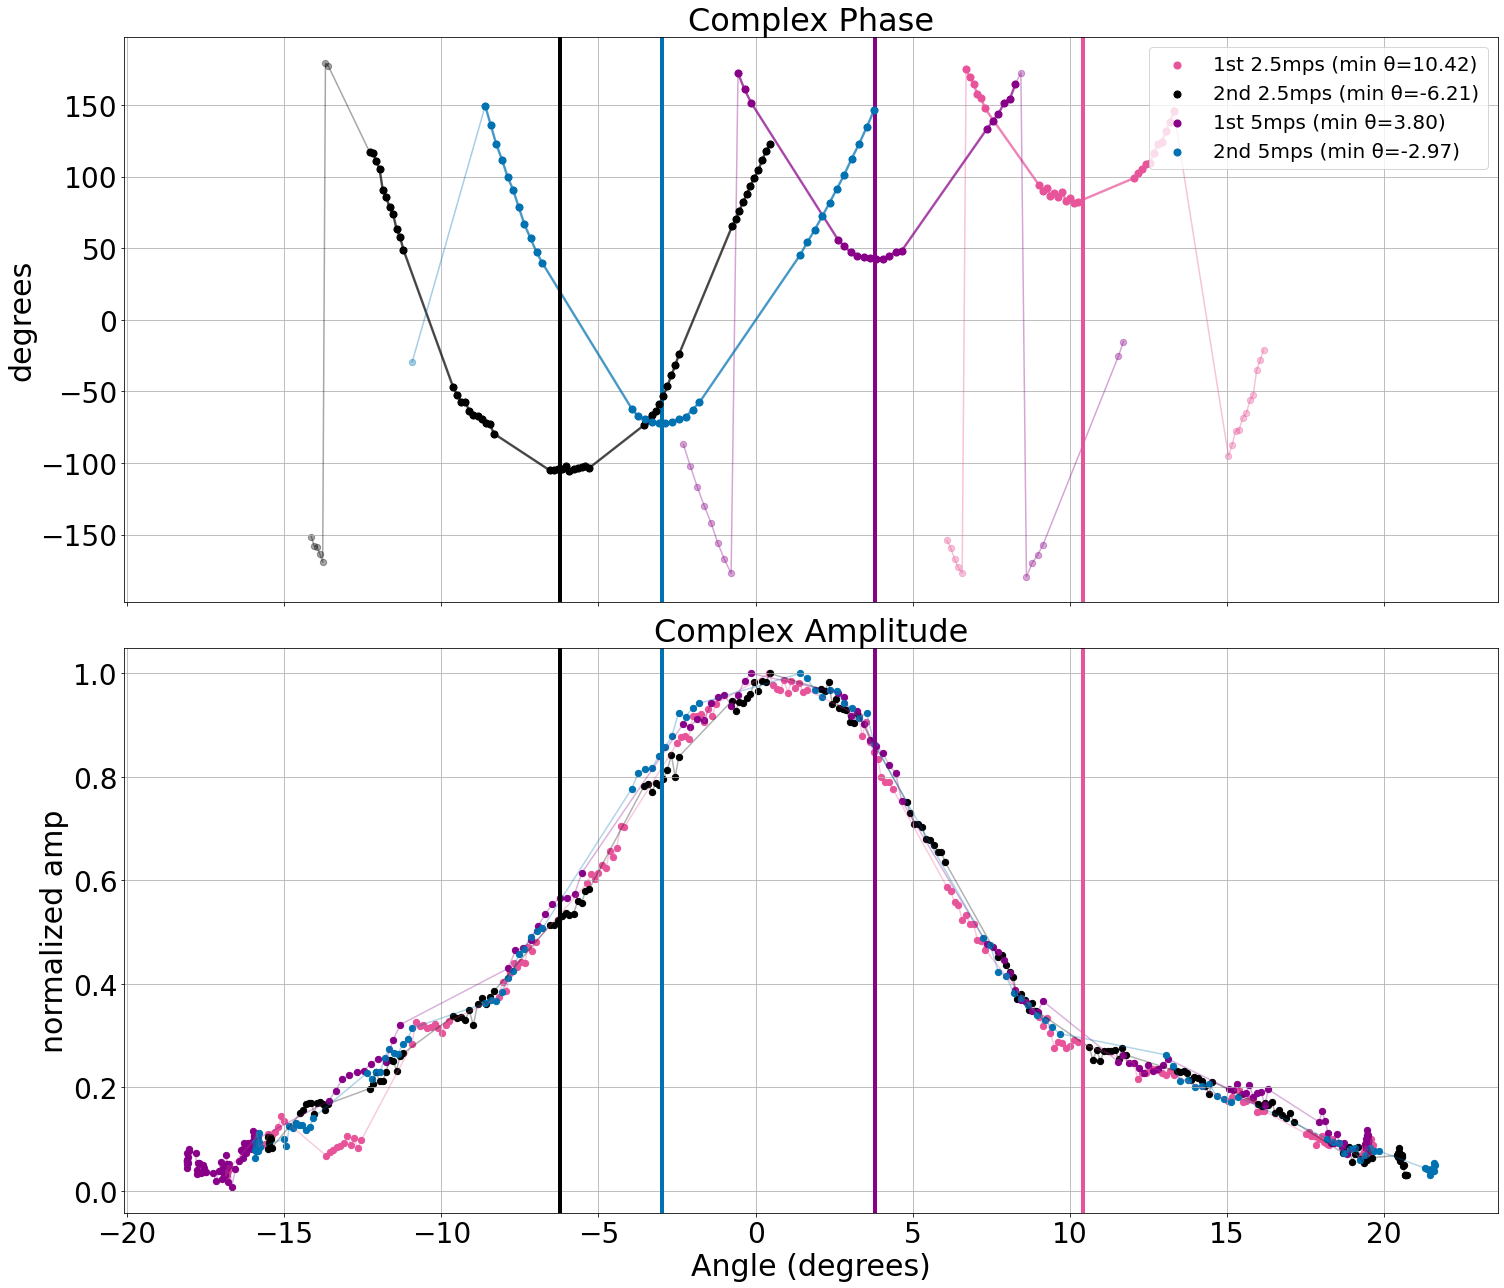

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Color palette for four distinct datasets
# ----------------------------------------
dataset_colors = [
    "#E7549A",  # pink
    "#000000",  # black
    "#880088",  # dark pink
    "#0072B2",  # blue
]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=dataset_colors)

# ----------------------------------------
# GLOBAL FONT SIZE CONTROL
# ----------------------------------------
plt.rcParams.update({
    "font.size": 25,
    "axes.titlesize": 32,
    "axes.labelsize": 30,
    "xtick.labelsize": 28,
    "ytick.labelsize": 28,
    "legend.fontsize": 20
})

def load_txt_data(filename):
    data = {}
    current_key = None
    current_vals = []
    with open(filename) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                if current_key is not None:
                    data[current_key] = np.array(current_vals).flatten()
                current_key = line[1:].strip()
                current_vals = []
            else:
                current_vals.extend([float(x) for x in line.split()])
        if current_key is not None:
            data[current_key] = np.array(current_vals).flatten()
    return data

# ----------------------------------------
# File list
# ----------------------------------------
files = ["2.5ms_final_data.txt", "5ms_final_data.txt"]

# ----------------------------------------
# Custom dataset labels
# ----------------------------------------
custom_labels = ["1st 2.5mps", "2nd 2.5mps", "1st 5mps", "2nd 5mps"]

# ----------------------------------------
# Vertical line positions
# ----------------------------------------
theta_lines = [
    10.420431817654052,
    -6.208035402573651,
    3.798585028688621,
    -2.9688922719587585,
]

# ----------------------------------------
# Inner and outer window half-widths (phase plot)
# ----------------------------------------
theta_inner_windows = [3.75, 7, 4.5, 7]   # highlighted region
theta_outer_windows = [6, 8, 8, 8]      # faint background region

# ----------------------------------------
# Helper: build mask for ONE region
# ----------------------------------------
def build_mask(theta_array, center, window):
    return (theta_array >= center - window) & (theta_array <= center + window)

# ----------------------------------------
# Create subplots (shared x-axis)
# ----------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(21, 18), sharex=True)

line_index = 0  # tracks which vertical line we are on

for fname in files:
    data = load_txt_data(fname)

    theta1, phase1, amp1 = data["theta1"], data["phase1"], data["amp1"]
    theta2, phase2, amp2 = data["theta2"], data["phase2"], data["amp2"]

    # ---- sort ----
    idx1 = np.argsort(theta1)
    theta1, phase1, amp1 = theta1[idx1], phase1[idx1], amp1[idx1]

    idx2 = np.argsort(theta2)
    theta2, phase2, amp2 = theta2[idx2], phase2[idx2], amp2[idx2]

    # ---- normalize amplitude ----
    amp1 = amp1 / np.max(amp1)
    amp2 = amp2 / np.max(amp2)

    # ---- masks ----
    inner_mask1 = build_mask(theta1, theta_lines[line_index], theta_inner_windows[line_index])
    outer_mask1 = build_mask(theta1, theta_lines[line_index], theta_outer_windows[line_index])

    inner_mask2 = build_mask(theta2, theta_lines[line_index + 1], theta_inner_windows[line_index + 1])
    outer_mask2 = build_mask(theta2, theta_lines[line_index + 1], theta_outer_windows[line_index + 1])

    # ---- select color and labels for this dataset ----
    color1 = dataset_colors[line_index]
    color2 = dataset_colors[line_index + 1]
    label1 = f"{custom_labels[line_index]} (min θ={theta_lines[line_index]:.2f})"
    label2 = f"{custom_labels[line_index + 1]} (min θ={theta_lines[line_index + 1]:.2f})"

    # ---- phase scatter ----
    # Outer faint region
    ax1.scatter(theta1[outer_mask1], phase1[outer_mask1], s=40, color=color1, alpha=0.35)
    ax1.scatter(theta2[outer_mask2], phase2[outer_mask2], s=40, color=color2, alpha=0.35)
    ax1.plot(theta1[outer_mask1], phase1[outer_mask1], linewidth=1.5, color=color1, alpha=0.35)
    ax1.plot(theta2[outer_mask2], phase2[outer_mask2], linewidth=1.5, color=color2, alpha=0.35)

    # Inner highlighted region
    ax1.scatter(theta1[inner_mask1], phase1[inner_mask1], s=50, color=color1, label=label1, zorder=5)
    ax1.scatter(theta2[inner_mask2], phase2[inner_mask2], s=50, color=color2, label=label2, zorder=5)
    ax1.plot(theta1[inner_mask1], phase1[inner_mask1], linewidth=2.5, color=color1, alpha=0.6)
    ax1.plot(theta2[inner_mask2], phase2[inner_mask2], linewidth=2.5, color=color2, alpha=0.6)

    # ---- amplitude (full) ----
    ax2.scatter(theta1, amp1, s=40, color=color1)
    ax2.scatter(theta2, amp2, s=40, color=color2)
    ax2.plot(theta1, amp1, linewidth=1.5, color=color1, alpha=0.3)
    ax2.plot(theta2, amp2, linewidth=1.5, color=color2, alpha=0.3)

    line_index += 2

# ---- vertical lines ----
for i, theta_v in enumerate(theta_lines):
    color = dataset_colors[i]
    ax1.axvline(theta_v, color=color, linestyle='-', linewidth=4)
    ax2.axvline(theta_v, color=color, linestyle='-', linewidth=4)

# ---- Labels and formatting ----
ax1.set_ylabel("degrees")
ax1.set_title("Complex Phase")
ax1.grid()
ax1.legend(loc='upper right', bbox_to_anchor=(1.0, 1.0))

# Expand y-axis so legend doesn't cover data
ymin, ymax = ax1.get_ylim()
#ax1.set_ylim(ymin - 0.05 * (ymax - ymin), ymax + 0.1 * (ymax - ymin))

ax2.set_xlabel("Angle (degrees)")
ax2.set_ylabel("normalized amp")
ax2.set_title("Complex Amplitude")
ax2.grid()
plt.tight_layout()
plt.show()

<ipython-input-11-bed91aeebd11>:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  base = plt.cm.get_cmap(base_cmap)


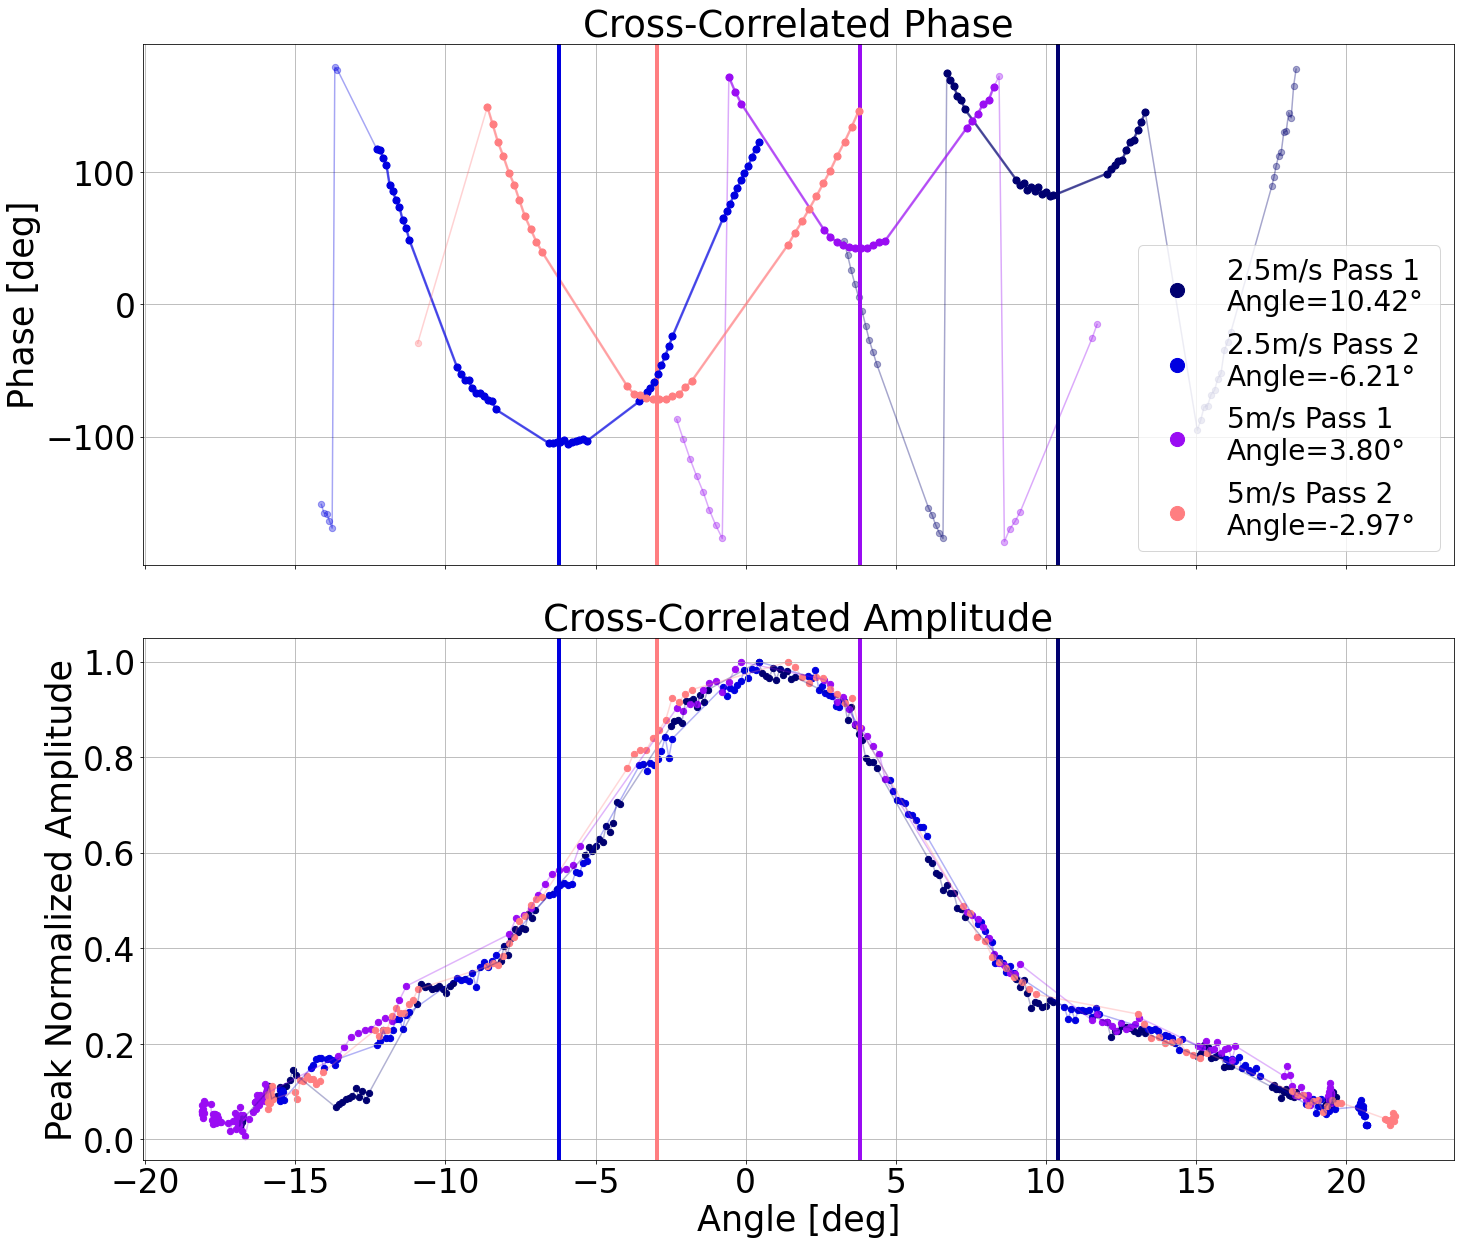

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.cm as cm

# ----------------------------------------
# Colormap system (FOLLOWING GUIDELINES)
# ----------------------------------------
def cm_to_discrete(base_cmap, N):
    base = plt.cm.get_cmap(base_cmap)
    colors = base(np.linspace(0, 1, N))
    return ListedColormap(colors)

colorz = cm_to_discrete(cm.gnuplot2, 10)

# ----------------------------------------
# Color palette for four distinct datasets
# (derived from colormap, not hardcoded)
# ----------------------------------------
dataset_colors = [
    colorz(1),   # pass 1
    colorz(2),   # pass 2
    colorz(4),   # pass 3
    colorz(6),   # pass 4
]

plt.rcParams['axes.prop_cycle'] = plt.cycler(color=dataset_colors)

# ----------------------------------------
# GLOBAL FONT SIZE CONTROL
# ----------------------------------------
plt.rcParams.update({
    "font.size": 30,
    "axes.titlesize": 37,
    "axes.labelsize": 35,
    "xtick.labelsize": 33,
    "ytick.labelsize": 33,
    "legend.fontsize": 28
})

def load_txt_data(filename):
    data = {}
    current_key = None
    current_vals = []
    with open(filename) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if line.startswith("#"):
                if current_key is not None:
                    data[current_key] = np.array(current_vals).flatten()
                current_key = line[1:].strip()
                current_vals = []
            else:
                current_vals.extend([float(x) for x in line.split()])
        if current_key is not None:
            data[current_key] = np.array(current_vals).flatten()
    return data

# ----------------------------------------
# File list
# ----------------------------------------
files = ["2.5ms_final_data.txt", "5ms_final_data.txt"]

# ----------------------------------------
# Custom dataset labels
# ----------------------------------------
custom_labels = ["2.5m/s Pass 1", "2.5m/s Pass 2", "5m/s Pass 1" , "5m/s Pass 2"]

# ----------------------------------------
# Vertical line positions
# ----------------------------------------
theta_lines = [
    10.420431817654052,
    -6.208035402573651,
    3.798585028688621,
    -2.9688922719587585,
]

# ----------------------------------------
# Inner and outer window half-widths (phase plot)
# ----------------------------------------
theta_inner_windows = [3.75, 7, 4.5, 7]   # highlighted region
theta_outer_windows = [8, 8, 8, 8]        # faint background region

# ----------------------------------------
# Helper: build mask for ONE region
# ----------------------------------------
def build_mask(theta_array, center, window):
    return (theta_array >= center - window) & (theta_array <= center + window)

# ----------------------------------------
# Create subplots (shared x-axis)
# ----------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(21, 18), sharex=True)

line_index = 0  # tracks which vertical line we are on

for fname in files:
    data = load_txt_data(fname)

    theta1, phase1, amp1 = data["theta1"], data["phase1"], data["amp1"]
    theta2, phase2, amp2 = data["theta2"], data["phase2"], data["amp2"]

    # ---- sort ----
    idx1 = np.argsort(theta1)
    theta1, phase1, amp1 = theta1[idx1], phase1[idx1], amp1[idx1]

    idx2 = np.argsort(theta2)
    theta2, phase2, amp2 = theta2[idx2], phase2[idx2], amp2[idx2]

    # ---- normalize amplitude ----
    amp1 = amp1 / np.max(amp1)
    amp2 = amp2 / np.max(amp2)

    # ---- masks ----
    inner_mask1 = build_mask(theta1, theta_lines[line_index], theta_inner_windows[line_index])
    outer_mask1 = build_mask(theta1, theta_lines[line_index], theta_outer_windows[line_index])

    inner_mask2 = build_mask(theta2, theta_lines[line_index + 1], theta_inner_windows[line_index + 1])
    outer_mask2 = build_mask(theta2, theta_lines[line_index + 1], theta_outer_windows[line_index + 1])

    # ---- select color and labels for this dataset ----
    color1 = dataset_colors[line_index]
    color2 = dataset_colors[line_index + 1]
    label1 = f"{custom_labels[line_index]} \nAngle={theta_lines[line_index]:.2f}°"
    label2 = f"{custom_labels[line_index + 1]} \nAngle={theta_lines[line_index + 1]:.2f}°"

    # ---- phase scatter ----
    # Outer faint region
    ax1.scatter(theta1[outer_mask1], phase1[outer_mask1], s=40, color=color1, alpha=0.35)
    ax1.scatter(theta2[outer_mask2], phase2[outer_mask2], s=40, color=color2, alpha=0.35)
    ax1.plot(theta1[outer_mask1], phase1[outer_mask1], linewidth=1.5, color=color1, alpha=0.35)
    ax1.plot(theta2[outer_mask2], phase2[outer_mask2], linewidth=1.5, color=color2, alpha=0.35)

    # Inner highlighted region
    ax1.scatter(theta1[inner_mask1], phase1[inner_mask1], s=50, color=color1, label=label1, zorder=5)
    ax1.scatter(theta2[inner_mask2], phase2[inner_mask2], s=50, color=color2, label=label2, zorder=5)
    ax1.plot(theta1[inner_mask1], phase1[inner_mask1], linewidth=2.5, color=color1, alpha=0.6)
    ax1.plot(theta2[inner_mask2], phase2[inner_mask2], linewidth=2.5, color=color2, alpha=0.6)

    # ---- amplitude (full) ----
    ax2.scatter(theta1, amp1, s=40, color=color1)
    ax2.scatter(theta2, amp2, s=40, color=color2)
    ax2.plot(theta1, amp1, linewidth=1.5, color=color1, alpha=0.3)
    ax2.plot(theta2, amp2, linewidth=1.5, color=color2, alpha=0.3)

    line_index += 2

# ---- vertical lines ----
for i, theta_v in enumerate(theta_lines):
    color = dataset_colors[i]
    ax1.axvline(theta_v, color=color, linestyle='-', linewidth=4)
    ax2.axvline(theta_v, color=color, linestyle='-', linewidth=4)

# ---- Labels and formatting ----
ax1.set_ylabel("Phase [deg]")
ax1.set_title("Cross-Correlated Phase")
ax1.grid()
ax1.legend(loc='lower right',markerscale=2) #bbox_to_anchor=(1.0, 1.0))

# Expand y-axis so legend doesn't cover data
ymin, ymax = ax1.get_ylim()
# ax1.set_ylim(ymin - 0.05 * (ymax - ymin), ymax + 0.1 * (ymax - ymin))

ax2.set_xlabel("Angle [deg]")
ax2.set_ylabel("Peak Normalized Amplitude")
ax2.set_title("Cross-Correlated Amplitude")
ax2.grid()

plt.tight_layout()
plt.show()

fig.savefig(
    "phase_amp_v_angle.png",
    dpi=300,
    bbox_inches="tight"
)